# Bài 2: Hồi quy logistic
**Học máy ứng dụng — Trường Đại học Văn Lang, Khoa Công nghệ Thông tin**

Notebook này làm lại toàn bộ bài thực hành `Lab02_Hoi_quy_logistic.pdf` trên bộ dữ liệu
`sinh_vien.csv` (120 sinh viên, 3 cột).

| Phần | Nội dung | Tương ứng trong tài liệu |
|---|---|---|
| A | 6 bước của bài thực hành | Mục 2 → Mục 7 (`c1` … `c6`) |
| B | 6 bài tập nộp | Mục 8 |

**Cách dùng:** chạy lần lượt từ trên xuống (`Shift + Enter`). Mỗi bước đều in ra con số để
đối chiếu với tài liệu — hai bên phải khớp tới từng chữ số. Mọi hình vẽ đều được lưu thêm một
bản vào thư mục `images/` cạnh notebook.

**Thư viện cần có:** `numpy`, `pandas`, `matplotlib`, `scikit-learn`.
Nếu máy chưa có thì mở cửa sổ lệnh và gõ:

```
pip install numpy pandas matplotlib scikit-learn
```

## 0. Chuẩn bị môi trường

Ô dưới đây nhập ba thư viện, đọc tệp dữ liệu một lần cho cả notebook và chuẩn bị thư mục `images/`.

Về đường dẫn: tài liệu quy ước tệp nằm ở `data/sinh_vien.csv`, nhưng nếu notebook đặt
cạnh tệp CSV thì đường dẫn chỉ là `sinh_vien.csv`. Ô này tự dò cả hai chỗ nên không cần sửa tay.

Hàm `luu_hinh` gọi `plt.savefig` **trước** `plt.show()`, vì `show` đóng hình lại và lưu sau
đó sẽ được một tệp trắng.

In [1]:
# -*- coding: utf-8 -*-
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Tìm tệp dữ liệu: ưu tiên bố cục data/ của tài liệu, nếu không có thì lấy tệp cùng thư mục.
DUONG_DAN = Path("data/sinh_vien.csv")
if not DUONG_DAN.exists():
    DUONG_DAN = Path("sinh_vien.csv")
if not DUONG_DAN.exists():
    raise FileNotFoundError(
        "Khong tim thay sinh_vien.csv. Hay dat notebook canh tep CSV, "
        "hoac tao thu muc data/ va bo tep vao do."
    )

print("Doc du lieu tu:", DUONG_DAN.resolve())

# Mọi hình vẽ được lưu thêm một bản vào images/ cạnh notebook.
THU_MUC_ANH = Path("images")
THU_MUC_ANH.mkdir(exist_ok=True)


def luu_hinh(ten_tep):
    """Lưu hình đang vẽ vào images/ rồi mới hiện ra màn hình."""
    plt.savefig(THU_MUC_ANH / ten_tep, dpi=150, bbox_inches="tight")
    plt.show()


# DejaVu Sans (phông mặc định của matplotlib) có đủ dấu tiếng Việt nên hình vẽ hiện đúng chữ.
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Hai màu dùng xuyên suốt bài: xanh cho lớp qua môn (1), đỏ cho lớp rớt môn (0).
MAU_QUA = "#2b6cb0"
MAU_ROT = "#e53e3e"

Doc du lieu tu: D:\HOC\HMUD\TH\02. Logistic Regression\sinh_vien.csv


---
# Phần A — Bài thực hành

## Bước 1 — Đọc bộ dữ liệu sinh viên *(Mục 2, `c1_doc_du_lieu.py`)*

**Bài toán đặt ra:** một giảng viên muốn biết trước sinh viên nào đang có nguy cơ rớt môn để còn
kịp nhắc nhở trước kỳ thi. Khác với bài 1 (đoán giá nhà — một con số trượt liên tục), ở bài này
thứ cần đoán chỉ có **hai khả năng**: qua hoặc rớt. Bài toán chỉ có hai nhãn như vậy gọi là
**phân loại nhị phân** (*binary classification*).

> 📌 **Quy ước nhãn phải nhớ suốt bài:** số **1** nghĩa là **qua môn**, số **0** nghĩa là
> **rớt môn**. Mọi công thức phía sau đều dựa vào quy ước này.

Ba lệnh mới so với bài 1:

- `df["qua_mon"].value_counts()` đếm xem mỗi giá trị xuất hiện bao nhiêu lần — với cột chỉ có
  0 và 1 thì biết ngay lớp nào nhiều hơn.
- `df["qua_mon"].mean()` lấy trung bình của cột 0 và 1, mà trung bình đó **chính là tỷ lệ số 1**.
  Đây là mẹo rất hay dùng trong phân loại nhị phân.
- `df.groupby("qua_mon")["gio_on"].mean()` tách dữ liệu thành hai nhóm theo nhãn rồi tính trung
  bình số giờ ôn của từng nhóm.

In [2]:
"""Bước 1: đọc bộ dữ liệu sinh viên và xem qua một lượt."""

df = pd.read_csv(DUONG_DAN)

print("Kich thuoc bang (so dong, so cot):", df.shape)
print()

print("Nam dong dau tien:")
print(df.head())
print()

# Cột qua_mon chỉ có hai giá trị, đếm số lần xuất hiện từng giá trị
print("So sinh vien theo ket qua:")
print(df["qua_mon"].value_counts())
print()

print("Ty le qua mon:", round(df["qua_mon"].mean(), 4))
print()

# So sánh số giờ ôn trung bình của hai nhóm
print("So gio on trung binh theo nhom:")
print(df.groupby("qua_mon")["gio_on"].mean().round(2))
print()

# Thói quen từ bài 1: luôn kiểm tra ô trống với mọi bộ dữ liệu mới
print("So o bi thieu trong tung cot:")
print(df.isna().sum())

Kich thuoc bang (so dong, so cot): (120, 3)

Nam dong dau tien:
   gio_on  diem_giua_ky  qua_mon
0     5.5           3.0        0
1    19.0           6.0        1
2    14.0           7.7        0
3    11.0           3.1        0
4    10.5           5.8        1

So sinh vien theo ket qua:
qua_mon
1    71
0    49
Name: count, dtype: int64

Ty le qua mon: 0.5917

So gio on trung binh theo nhom:
qua_mon
0     8.29
1    19.89
Name: gio_on, dtype: float64

So o bi thieu trong tung cot:
gio_on          0
diem_giua_ky    0
qua_mon         0
dtype: int64


**Ba cột trong tệp** *(Bảng 2 của tài liệu)*

| Tên cột | Ý nghĩa | Đơn vị | Khoảng giá trị |
|---|---|---|---|
| `gio_on` | Số giờ ôn tập trước kỳ thi | giờ | 0.0 → 29.5 |
| `diem_giua_ky` | Điểm bài kiểm tra giữa kỳ | điểm | 0.0 → 10.0 |
| `qua_mon` | **Kết quả cuối môn** | 0 hoặc 1 | 0 là rớt, 1 là qua |

Cột `qua_mon` là thứ ta muốn đoán nên gọi là **biến mục tiêu** (*target*). Hai cột còn lại là
**đặc trưng** (*feature*). Từ Bước 2 tới Bước 5 ta chỉ dùng một đặc trưng là `gio_on` cho dễ hình
dung, tới Bước 6 mới thêm `diem_giua_ky`.

**Đọc kết quả:**

1. Hai lớp **không lệch nhau quá đáng**: 71 bạn qua và 49 bạn rớt, tỷ lệ qua là 0.5917. Đây là
   chuyện tốt, vì khi hai lớp lệch nhau nhiều thì việc đánh giá mô hình khó hơn hẳn (Bước 4 sẽ
   nói kỹ).
2. **Con số quan trọng nhất:** nhóm rớt ôn trung bình **8.29 giờ**, nhóm qua ôn trung bình
   **19.89 giờ** — cách nhau hơn hai lần, nghĩa là số giờ ôn thật sự phân biệt được hai nhóm.
   Nếu hai con số này gần bằng nhau thì có cố mấy cũng không xây được mô hình tốt.

> 💡 **Thói quen nên giữ:** với mọi bài phân loại, việc đầu tiên là so trung bình của từng đặc
> trưng giữa các lớp. Đặc trưng nào chênh lệch rõ thì đặc trưng đó hữu ích — cách kiểm tra rẻ
> tiền nhất trước khi bỏ công huấn luyện.

### Vì sao không dùng lại đường thẳng của bài 1 *(Mục 2.4 — Hình 1)*

Thử coi nhãn 0 và 1 là hai con số rồi khớp một đường thẳng y hệt bài 1 xem chuyện gì xảy ra.

Duong thang: y = 0.0459 * gio_on -0.1032
Tren dai du lieu, duong thang nhan gia tri tu -0.103 toi 1.250
So ban bi gan gia tri ngoai khoang 0 toi 1: 25 / 120


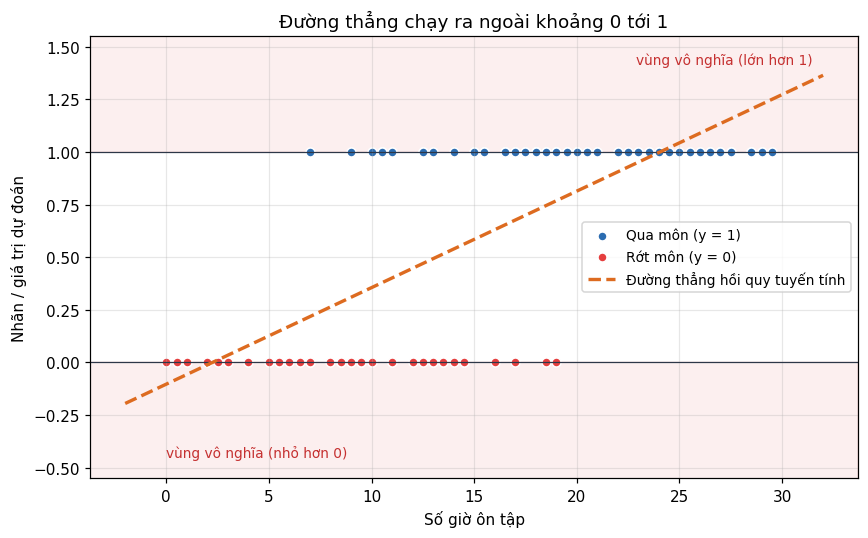

In [3]:
"""Mục 2.4: ép đường thẳng của bài 1 lên nhãn 0 và 1."""

from sklearn.linear_model import LinearRegression

duong_thang = LinearRegression().fit(df[["gio_on"]], df["qua_mon"])
gia_tri_thang = duong_thang.predict(df[["gio_on"]])
so_ban_ngoai_khoang = int(((gia_tri_thang < 0) | (gia_tri_thang > 1)).sum())

print(f"Duong thang: y = {duong_thang.coef_[0]:.4f} * gio_on {duong_thang.intercept_:+.4f}")
print(f"Tren dai du lieu, duong thang nhan gia tri tu "
      f"{gia_tri_thang.min():.3f} toi {gia_tri_thang.max():.3f}")
print(f"So ban bi gan gia tri ngoai khoang 0 toi 1: {so_ban_ngoai_khoang} / {len(df)}")

nhom_qua = df[df["qua_mon"] == 1]
nhom_rot = df[df["qua_mon"] == 0]
luoi_gio = np.linspace(-2, 32, 200)

plt.figure()
plt.axhspan(1, 1.6, color=MAU_ROT, alpha=0.08)
plt.axhspan(-0.6, 0, color=MAU_ROT, alpha=0.08)
plt.axhline(0, color="#2d3748", linewidth=0.8)
plt.axhline(1, color="#2d3748", linewidth=0.8)
plt.scatter(nhom_qua["gio_on"], nhom_qua["qua_mon"], s=35, color=MAU_QUA,
            edgecolor="white", label="Qua môn (y = 1)")
plt.scatter(nhom_rot["gio_on"], nhom_rot["qua_mon"], s=35, color=MAU_ROT,
            edgecolor="white", label="Rớt môn (y = 0)")
plt.plot(luoi_gio, duong_thang.predict(pd.DataFrame({"gio_on": luoi_gio})), "--",
         color="#dd6b20", linewidth=2.2, label="Đường thẳng hồi quy tuyến tính")
plt.text(31.5, 1.42, "vùng vô nghĩa (lớn hơn 1)", ha="right", color="#c53030", fontsize=9)
plt.text(0, -0.45, "vùng vô nghĩa (nhỏ hơn 0)", color="#c53030", fontsize=9)
plt.ylim(-0.55, 1.55)
plt.xlabel("Số giờ ôn tập")
plt.ylabel("Nhãn / giá trị dự đoán")
plt.title("Đường thẳng chạy ra ngoài khoảng 0 tới 1")
plt.legend(loc="center right", fontsize=9)
plt.tight_layout()
luu_hinh("hinh1_duong_thang_ra_ngoai_0_1.png")

Trên chính dải dữ liệu, đường thẳng nhận giá trị từ **−0.103 tới 1.250**, và có **25 trong 120
bạn** bị gán một giá trị nằm ngoài khoảng 0 tới 1.

Một giá trị như 1.250 không đọc được thành gì cả — "khả năng qua môn bằng 125 phần trăm" là câu
vô nghĩa. Gốc rễ của vấn đề là **một đường thẳng kéo dài ra hai phía thì vô tận**, nên không có
cách nào giữ nó trong khoảng 0 tới 1.

Điều ta cần là một hàm nhận vào một số thực bất kỳ rồi trả ra một số **luôn nằm giữa 0 và 1**.
Hàm đó tên là **sigmoid**.

---
## Bước 2 — Hàm sigmoid *(Mục 3, `c2_sigmoid.py`)*

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Chữ $\sigma$ đọc là *xích ma*, còn $e$ là hằng số Euler, xấp xỉ 2.718. Chưa cần chứng minh gì,
chỉ cần nắm ba tính chất:

- Khi $z$ rất âm thì $e^{-z}$ rất lớn, mẫu số rất lớn nên $\sigma(z)$ **tiến về 0**.
- Khi $z$ rất dương thì $e^{-z}$ tiến về 0, mẫu số tiến về 1 nên $\sigma(z)$ **tiến về 1**.
- Khi $z = 0$ thì $e^0 = 1$, nên $\sigma(0)$ **đúng bằng 1/2**.

Ô dưới làm ba việc: in bảng giá trị để thấy hình dạng của hàm bằng con số, kiểm chứng tính chất
$\sigma(-z) = 1 - \sigma(z)$, và thử một mô hình giả định $w = 0.4$, $b = -5$.

In [4]:
"""Bước 2: làm quen hàm sigmoid bằng tay trước khi gọi thư viện."""


def sigmoid(z):
    """Ep mot so thuc bat ky ve khoang tu 0 toi 1."""
    return 1 / (1 + np.exp(-z))


print("Bang gia tri cua ham sigmoid")
print(" z        sigmoid(z)")
for z in [-6, -4, -2, -1, 0, 1, 2, 4, 6]:
    print(f"{z:3d}        {sigmoid(z):.4f}")
print()

# Hai tính chất cần tự kiểm chứng
print("Kiem tra sigmoid(-z) = 1 - sigmoid(z):")
for z in [1.0, 2.5, 3.7]:
    trai = sigmoid(-z)
    phai = 1 - sigmoid(z)
    print(f"  z = {z}:  {trai:.6f}  va  {phai:.6f}")
print()

# Thử với một mô hình giả định w = 0.4 và b = -5
w, b = 0.4, -5.0
print(f"Mo hinh gia dinh: w = {w}, b = {b}")
print(" So gio on    z = w*x + b    Xac suat qua mon")
for gio in [5, 10, 12.5, 15, 20, 25]:
    z = w * gio + b
    print(f"  {gio:5.1f}        {z:6.2f}          {sigmoid(z):.4f}")

Bang gia tri cua ham sigmoid
 z        sigmoid(z)
 -6        0.0025
 -4        0.0180
 -2        0.1192
 -1        0.2689
  0        0.5000
  1        0.7311
  2        0.8808
  4        0.9820
  6        0.9975

Kiem tra sigmoid(-z) = 1 - sigmoid(z):
  z = 1.0:  0.268941  va  0.268941
  z = 2.5:  0.075858  va  0.075858
  z = 3.7:  0.024127  va  0.024127

Mo hinh gia dinh: w = 0.4, b = -5.0
 So gio on    z = w*x + b    Xac suat qua mon
    5.0         -3.00          0.0474
   10.0         -1.00          0.2689
   12.5          0.00          0.5000
   15.0          1.00          0.7311
   20.0          3.00          0.9526
   25.0          5.00          0.9933


**Đọc ba bảng:**

- Bảng thứ nhất đi từ 0.0025 lên 0.9975 nhưng **không bao giờ chạm 0 hay chạm 1**. Mô hình
  logistic không bao giờ nói chắc chắn tuyệt đối — điều này hợp lý vì thực tế cũng không có gì
  chắc chắn tuyệt đối.
- Bảng thứ hai xác nhận $\sigma(-z) = 1 - \sigma(z)$ tới sáu chữ số thập phân. Ý nghĩa đời thường:
  **xác suất qua môn cộng xác suất rớt môn luôn bằng 1**.
- Bảng thứ ba là chỗ quan trọng nhất. Với $w = 0.4$, $b = -5$, bạn ôn **12.5 giờ** cho $z$ bằng
  đúng 0 nên xác suất qua môn **đúng bằng 0.5**. Bạn ôn 5 giờ chỉ được 0.0474, còn bạn ôn 25 giờ
  được tới 0.9933.

> **Hai bước luôn đi cùng nhau:** mô hình logistic tính phần tuyến tính $z = wx + b$ y hệt bài 1,
> rồi bọc sigmoid lên trên để ép $z$ về khoảng 0 tới 1. Vì phần tuyến tính giữ nguyên nên tên gọi
> mới có chữ *hồi quy*, dù đây là bài toán phân loại.

> ⚠️ **Chú ý dấu trừ:** công thức là $1/(1+e^{-z})$, trong numpy phải viết `np.exp(-z)` chứ không
> phải `np.exp(z)`. Viết nhầm dấu thì đồ thị lật ngược và mô hình đoán ngược hoàn toàn **mà không
> báo lỗi gì cả**.

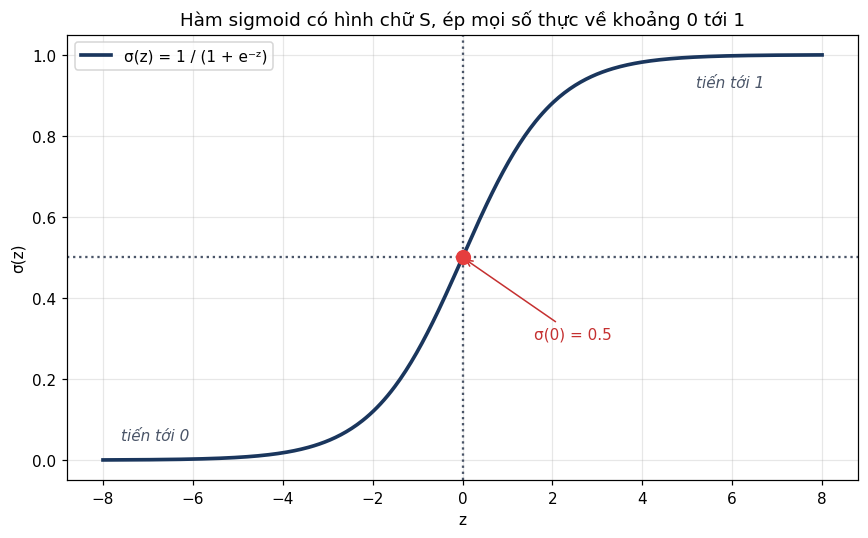

In [5]:
# Hình 2: đồ thị hàm sigmoid
luoi_z = np.linspace(-8, 8, 400)

plt.figure()
plt.plot(luoi_z, sigmoid(luoi_z), color="#1a365d", linewidth=2.4, label="σ(z) = 1 / (1 + e⁻ᶻ)")
plt.axhline(0.5, linestyle=":", color="#4a5568")
plt.axvline(0, linestyle=":", color="#4a5568")
plt.scatter([0], [0.5], s=80, color=MAU_ROT, zorder=5)
plt.annotate("σ(0) = 0.5", xy=(0, 0.5), xytext=(1.6, 0.3), color="#c53030",
             arrowprops=dict(arrowstyle="->", color="#c53030"))
plt.text(5.2, 0.92, "tiến tới 1", fontstyle="italic", color="#4a5568")
plt.text(-7.6, 0.05, "tiến tới 0", fontstyle="italic", color="#4a5568")
plt.xlabel("z")
plt.ylabel("σ(z)")
plt.title("Hàm sigmoid có hình chữ S, ép mọi số thực về khoảng 0 tới 1")
plt.legend(loc="upper left")
plt.tight_layout()
luu_hinh("hinh2_ham_sigmoid.png")

Tên gọi *sigmoid* nghĩa là **có hình chữ S** — nhìn hình là thấy ngay vì sao. Đường cong đi qua
điểm $(0,\ 0.5)$, phẳng dần ở hai đầu và dốc nhất ở giữa.

---
## Bước 3 — Khớp mô hình bằng scikit-learn *(Mục 4, `c3_khop_mo_hinh.py`)*

Ba bước chuẩn của scikit-learn học ở bài 1 dùng lại y nguyên, chỉ đổi tên lớp mô hình
*(Bảng 3)*:

| Bước | Bài 1 | Bài 2 |
|---|---|---|
| 1 | `LinearRegression()` | `LogisticRegression()` |
| 2 | `.fit(X, y)` | `.fit(X, y)` giống hệt |
| 3 | `.predict(X_moi)` | `.predict` **hoặc** `.predict_proba` |

Chỉ bước 3 có lựa chọn mới: `predict_proba` trả về **xác suất**, còn `predict` trả thẳng **nhãn**
0 hoặc 1. Bước 5 sẽ cho thấy vì sao nhiều khi ta cần xác suất chứ không cần nhãn.

> 🔍 **Chỗ sai kinh điển:** `X = df[["gio_on"]]` có **HAI** cặp ngoặc vuông (bảng hai chiều), còn
> `y = df["qua_mon"]` chỉ **MỘT** cặp (dãy một chiều). Viết nhầm một cặp cho `X` thì chương trình
> dừng với lỗi `Expected a 2-dimensional container but got pandas.Series`.

In [6]:
"""Bước 3: để scikit-learn tìm w và b từ dữ liệu thật."""

from sklearn.linear_model import LogisticRegression

# X phải là bảng hai chiều nên viết hai cặp ngoặc vuông.
# y là dãy một chiều nên chỉ một cặp.
X = df[["gio_on"]]
y = df["qua_mon"]

mo_hinh = LogisticRegression()
mo_hinh.fit(X, y)

w = float(mo_hinh.coef_[0][0])
b = float(mo_hinh.intercept_[0])

print(f"He so goc  w = {w:.6f}")
print(f"He so chan b = {b:.6f}")
print()

# Số giờ ôn mà mô hình phân vân đúng năm mươi năm mươi
print(f"So gio on ung voi xac suat 0.5: {-b / w:.2f} gio")
print()

can_moi = pd.DataFrame({"gio_on": [5.0, 10.0, 13.0, 20.0, 28.0]})
xac_suat = mo_hinh.predict_proba(can_moi)[:, 1]
nhan = mo_hinh.predict(can_moi)

print("Du doan cho nam ban moi:")
print(" So gio on    Xac suat qua    Nhan mo hinh dua ra")
for gio, p, n in zip(can_moi["gio_on"], xac_suat, nhan):
    print(f"  {gio:5.1f}        {p:.4f}             {n}")

He so goc  w = 0.392819
He so chan b = -5.064890

So gio on ung voi xac suat 0.5: 12.89 gio

Du doan cho nam ban moi:
 So gio on    Xac suat qua    Nhan mo hinh dua ra
    5.0        0.0431             0
   10.0        0.2429             0
   13.0        0.5104             1
   20.0        0.9422             1
   28.0        0.9974             1


**Đọc kết quả:** máy tìm được $w = 0.392819$ và $b = -5.064890$, nên mô hình đầy đủ là

$$\hat{y} = \sigma(0.3928\,x - 5.0649)$$

với $x$ là số giờ ôn tập và $\hat{y}$ là xác suất qua môn.

- $w$ **dương** → ôn càng nhiều thì xác suất qua càng cao. Nếu chạy ra $w$ âm thì gần như chắc
  chắn có gì đó sai (ví dụ đổi nhầm nhãn).
- Con số đáng nhớ nhất là **12.89 giờ** — nghiệm của $wx + b = 0$, tức $x = -b/w$. Dưới mốc này
  mô hình nghiêng về rớt, trên mốc này nghiêng về qua.
- Bạn ôn 5 giờ chỉ được 0.0431, gần như chắc rớt. Bạn ôn 13 giờ được 0.5104 — nhỉnh hơn phân vân
  một chút, đúng như dự đoán vì 13 chỉ nhiều hơn 12.89 một chút. Bạn ôn 28 giờ được 0.9974.

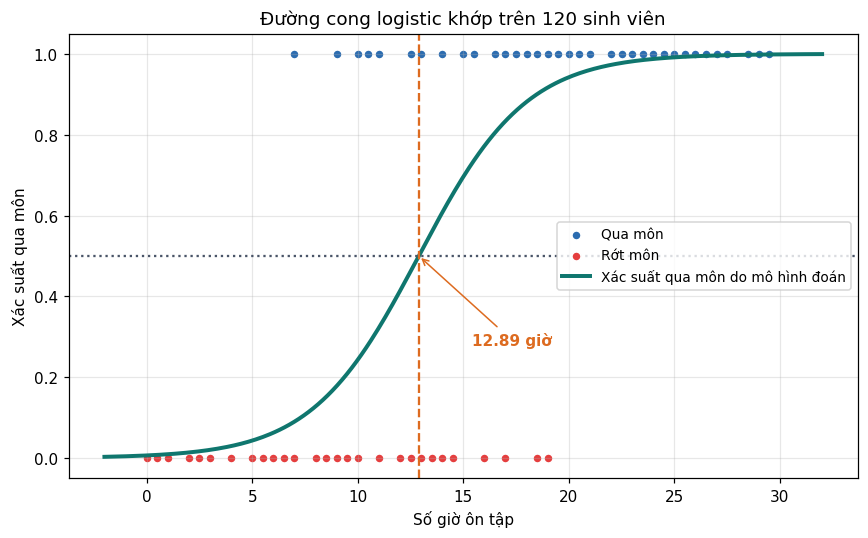

Them 1 gio on thi xac suat qua mon tang bao nhieu?
  tu  3.0 len  4.0 gio: 0.0201 -> 0.0295   (tang +0.0094)
  tu 12.5 len 13.5 gio: 0.4614 -> 0.5593   (tang +0.0978)
  tu 26.0 len 27.0 gio: 0.9942 -> 0.9961   (tang +0.0019)


In [7]:
# Hình 3: đường cong logistic khớp trên 120 sinh viên
luoi_gio = np.linspace(-2, 32, 300)
xac_suat_luoi = mo_hinh.predict_proba(pd.DataFrame({"gio_on": luoi_gio}))[:, 1]
moc_nua_nua = -b / w

plt.figure()
plt.scatter(nhom_qua["gio_on"], nhom_qua["qua_mon"], s=35, color=MAU_QUA,
            edgecolor="white", label="Qua môn")
plt.scatter(nhom_rot["gio_on"], nhom_rot["qua_mon"], s=35, color=MAU_ROT,
            edgecolor="white", label="Rớt môn")
plt.plot(luoi_gio, xac_suat_luoi, color="#0f766e", linewidth=2.6,
         label="Xác suất qua môn do mô hình đoán")
plt.axhline(0.5, linestyle=":", color="#4a5568")
plt.axvline(moc_nua_nua, linestyle="--", color="#dd6b20")
plt.annotate(f"{moc_nua_nua:.2f} giờ", xy=(moc_nua_nua, 0.5), xytext=(moc_nua_nua + 2.5, 0.28),
             color="#dd6b20", fontweight="bold",
             arrowprops=dict(arrowstyle="->", color="#dd6b20"))
plt.xlabel("Số giờ ôn tập")
plt.ylabel("Xác suất qua môn")
plt.title("Đường cong logistic khớp trên 120 sinh viên")
plt.legend(loc="center right", fontsize=9)
plt.tight_layout()
luu_hinh("hinh3_duong_cong_logistic.png")

# Thêm một giờ ôn làm xác suất tăng bao nhiêu? Tùy chỗ đứng trên đường cong chữ S.
print("Them 1 gio on thi xac suat qua mon tang bao nhieu?")
for gio in [3.0, 12.5, 26.0]:
    p_truoc = sigmoid(w * gio + b)
    p_sau = sigmoid(w * (gio + 1) + b)
    print(f"  tu {gio:4.1f} len {gio + 1:4.1f} gio: {p_truoc:.4f} -> {p_sau:.4f}"
          f"   (tang {p_sau - p_truoc:+.4f})")

> ⚠️ **Đừng đọc $w$ như hệ số của bài 1.** Ở hồi quy tuyến tính, $w$ là mức tăng của đầu ra khi
> $x$ tăng một đơn vị. Ở hồi quy logistic, $w$ là mức tăng của $z$, **không phải** của xác suất.
> Ôn thêm một giờ không làm xác suất tăng thêm 0.3928.
>
> Bảng ngay trên cho thấy rõ: quanh mốc 12.89 giờ (giữa đường cong), thêm một giờ làm xác suất
> nhích gần 0.1; còn ở hai đầu, khi xác suất đã gần 0 hoặc gần 1, thêm một giờ gần như không đổi gì.

---
## Bước 4 — Chấm điểm mô hình *(Mục 5, `c4_danh_gia.py`)*

### Ma trận nhầm lẫn

Với bài toán hai nhãn, mỗi dự đoán rơi vào đúng một trong bốn ô. Bảng gom bốn ô đó gọi là
**ma trận nhầm lẫn** (*confusion matrix*) *(Bảng 4)*:

| Viết tắt | Tên đầy đủ | Nghĩa trong bài này |
|---|---|---|
| TP | True Positive | Đoán qua, thật sự qua. Đoán đúng. |
| TN | True Negative | Đoán rớt, thật sự rớt. Đoán đúng. |
| FP | False Positive | Đoán qua, nhưng thật ra rớt. Đoán sai. |
| FN | False Negative | Đoán rớt, nhưng thật ra qua. Đoán sai. |

> 💡 **Cách nhớ:** chữ thứ **hai** cho biết mô hình đoán gì (P = đoán lớp 1, N = đoán lớp 0).
> Chữ thứ **nhất** cho biết đoán đó đúng hay sai (T = đúng, F = sai). Ghép lại, FP đọc là
> *đoán lớp 1 nhưng sai*, tức thật ra nó thuộc lớp 0.

### Chia dữ liệu rồi chấm điểm

Quy tắc của bài 1 vẫn nguyên giá trị: **học trên dữ liệu nào thì không được chấm điểm trên dữ
liệu đó**. Điểm mới ở bài này là tham số `stratify=y`.

> **Vì sao cần `stratify`:** bộ dữ liệu có khoảng 59% bạn qua. Nếu chia ngẫu nhiên tự do, tập kiểm
> tra có thể vô tình chứa toàn bạn qua môn và khi đó không chấm điểm được gì cả. `stratify=y` buộc
> máy giữ đúng tỷ lệ 59% đó ở cả tập học lẫn tập kiểm tra. Với bài phân loại, gần như lúc nào
> cũng nên đặt tham số này.

In [8]:
"""Bước 4: chia dữ liệu rồi chấm điểm mô hình bằng bốn thước đo."""

from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_score, recall_score)
from sklearn.model_selection import train_test_split

X = df[["gio_on"]]
y = df["qua_mon"]

# stratify=y giữ đúng tỷ lệ qua và rớt ở cả hai phần sau khi chia
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

print("So sinh vien de hoc     :", len(X_train))
print("So sinh vien de kiem tra:", len(X_test))
print()

mo_hinh = LogisticRegression()
mo_hinh.fit(X_train, y_train)

y_pred = mo_hinh.predict(X_test)

# Thứ tự bốn ô do scikit-learn quy định là TN, FP, FN, TP
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print("Ma tran nham lan")
print(f"  TN = {tn:2d}   doan rot, that su rot")
print(f"  FP = {fp:2d}   doan qua, that ra rot")
print(f"  FN = {fn:2d}   doan rot, that ra qua")
print(f"  TP = {tp:2d}   doan qua, that su qua")
print()

print(f"Accuracy  = {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision = {precision_score(y_test, y_pred):.4f}")
print(f"Recall    = {recall_score(y_test, y_pred):.4f}")
print(f"F1        = {f1_score(y_test, y_pred):.4f}")
print()

# Tự tính lại bằng tay để đối chiếu với thư viện
print("Tu tinh lai bang cong thuc:")
n = len(y_test)
print(f"  Accuracy  = ({tp} + {tn}) / {n} = {(tp + tn) / n:.4f}")
print(f"  Precision = {tp} / ({tp} + {fp}) = {tp / (tp + fp):.4f}")
print(f"  Recall    = {tp} / ({tp} + {fn}) = {tp / (tp + fn):.4f}")

So sinh vien de hoc     : 90
So sinh vien de kiem tra: 30

Ma tran nham lan
  TN =  9   doan rot, that su rot
  FP =  3   doan qua, that ra rot
  FN =  1   doan rot, that ra qua
  TP = 17   doan qua, that su qua

Accuracy  = 0.8667
Precision = 0.8500
Recall    = 0.9444
F1        = 0.8947

Tu tinh lai bang cong thuc:
  Accuracy  = (17 + 9) / 30 = 0.8667
  Precision = 17 / (17 + 3) = 0.8500
  Recall    = 17 / (17 + 1) = 0.9444


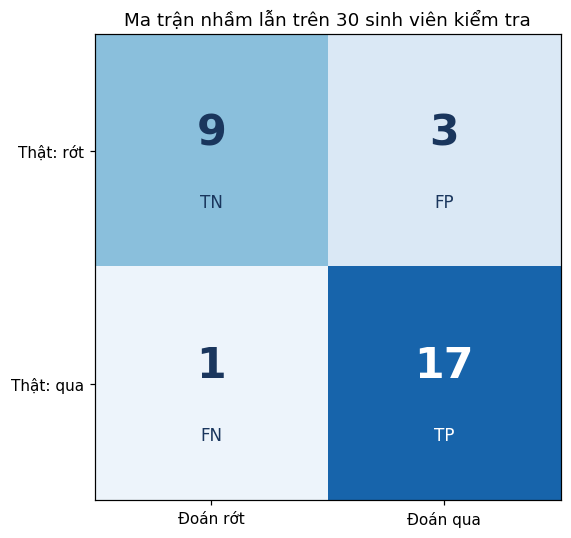

In [9]:
# Hình 4: ma trận nhầm lẫn trên 30 sinh viên của tập kiểm tra
ma_tran = confusion_matrix(y_test, y_pred)
ten_o = [["TN", "FP"], ["FN", "TP"]]

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.imshow(ma_tran, cmap="Blues", vmin=0, vmax=ma_tran.max() * 1.25)
for hang in range(2):
    for cot in range(2):
        mau_chu = "white" if ma_tran[hang, cot] > ma_tran.max() * 0.6 else "#1a365d"
        ax.text(cot, hang - 0.08, str(ma_tran[hang, cot]), ha="center", va="center",
                fontsize=28, fontweight="bold", color=mau_chu)
        ax.text(cot, hang + 0.22, ten_o[hang][cot], ha="center", va="center",
                fontsize=11, color=mau_chu)
ax.set_xticks([0, 1], ["Đoán rớt", "Đoán qua"])
ax.set_yticks([0, 1], ["Thật: rớt", "Thật: qua"])
ax.grid(False)
ax.set_title(f"Ma trận nhầm lẫn trên {len(y_test)} sinh viên kiểm tra")
plt.tight_layout()
luu_hinh("hinh4_ma_tran_nham_lan.png")

Trong 30 bạn của tập kiểm tra, mô hình đoán đúng **26 bạn** (hai ô trên đường chéo, 9 + 17) và
sai **4 bạn**. Bốn bạn sai chia làm hai loại: **3 bạn kiểu FP** và **1 bạn kiểu FN**.

### Bốn thước đo

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN} \qquad
\text{Precision} = \frac{TP}{TP + FP}$$

$$\text{Recall} = \frac{TP}{TP + FN} \qquad
F_1 = 2\cdot\frac{\text{Precision}\times\text{Recall}}{\text{Precision}+\text{Recall}}$$

Đọc từng con số bằng lời:

- **Accuracy = 0.8667** → mô hình đoán đúng khoảng 87% số bạn.
- **Precision = 0.8500** → trong **20 bạn mà mô hình nói sẽ qua**, có 17 bạn qua thật.
- **Recall = 0.9444** → trong **18 bạn thật sự qua môn**, mô hình tìm ra được 17 bạn.
- **$F_1$ = 0.8947** → con số gộp precision và recall lại cho tiện so sánh.

Ở đây recall cao hơn precision, nghĩa là mô hình **hơi dễ tính**: bắt được gần hết các bạn qua
môn, nhưng đổi lại báo nhầm 3 bạn.

> 💡 **Mẹo phân biệt precision và recall:** cả hai đều có $TP$ ở tử số, chỉ khác mẫu số.
> Precision chia cho **những gì mô hình nói** ($TP + FP$). Recall chia cho **những gì có thật**
> ($TP + FN$).

> ⚠️ **Accuracy một mình có thể đánh lừa.** Giả sử một lớp có 100 sinh viên mà chỉ 5 bạn rớt. Một
> mô hình lười biếng cứ đoán mọi bạn đều qua sẽ đạt accuracy 0.95, nghe rất giỏi — nhưng không bắt
> được bạn nào trong 5 bạn cần cảnh báo. Nếu vẫn lấy lớp dương là qua môn thì recall của mô hình
> lười đó bằng 1.00, nghe càng đẹp; phải đổi lớp dương sang rớt môn mới lòi ra sự thật (recall = 0).
> **Mỗi lần báo cáo một con số, luôn phải nói rõ đang tính cho lớp nào.**

In [10]:
# Làm thêm: classification_report in một lượt cả bốn thước đo cho TỪNG lớp.
# Bài tập 6 sẽ quay lại dòng "rot (0)" của bảng này.
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=["rot (0)", "qua (1)"], digits=4))

              precision    recall  f1-score   support

     rot (0)     0.9000    0.7500    0.8182        12
     qua (1)     0.8500    0.9444    0.8947        18

    accuracy                         0.8667        30
   macro avg     0.8750    0.8472    0.8565        30
weighted avg     0.8700    0.8667    0.8641        30



---
## Bước 5 — Ngưỡng quyết định *(Mục 6, `c5_doi_nguong.py`)*

### Mô hình trả về xác suất, không phải nhãn

Hàm `predict` rất tiện nhưng nó giấu mất một bước. Thực ra mô hình chỉ trả về một xác suất, rồi
`predict` tự so xác suất đó với **0.5** để ra nhãn. Con số 0.5 gọi là **ngưỡng** (*threshold*), và
nó là lựa chọn mặc định chứ không phải chân lý.

$$\hat{c} = 1 \text{ nếu } \hat{y} \ge t, \qquad \hat{c} = 0 \text{ nếu } \hat{y} < t$$

Ở đây $\hat{y}$ là xác suất mô hình trả về, $\hat{c}$ là nhãn cuối cùng, còn $t$ là ngưỡng do ta chọn.

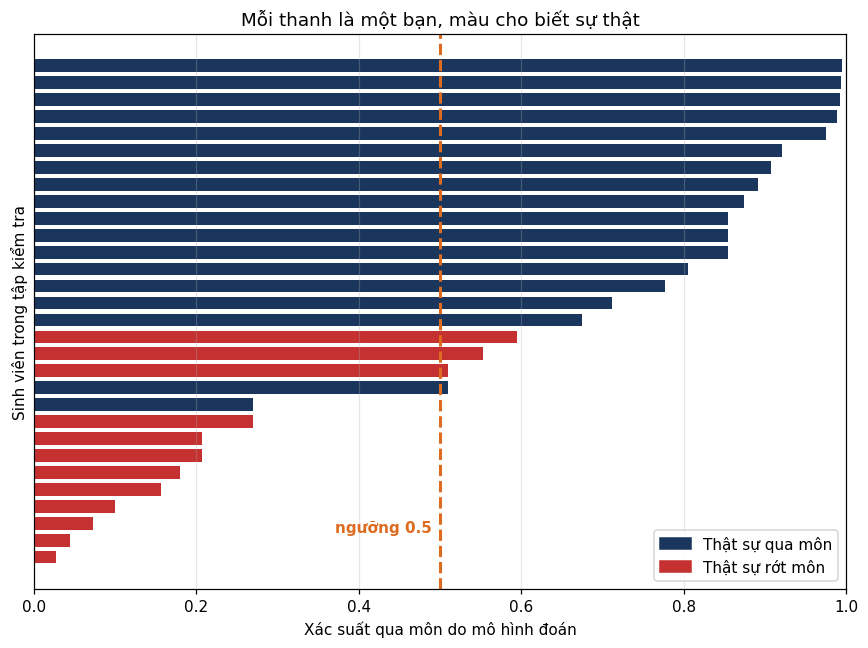

So thanh do nam ben phai nguong (FP): 3
So thanh xanh nam ben trai nguong (FN): 1


In [11]:
# Hình 5: xác suất mô hình gán cho từng bạn trong tập kiểm tra, xếp tăng dần
from matplotlib.patches import Patch

xac_suat_kt = mo_hinh.predict_proba(X_test)[:, 1]
thu_tu = np.argsort(xac_suat_kt)
xac_suat_sap_xep = xac_suat_kt[thu_tu]
nhan_that_sap_xep = y_test.to_numpy()[thu_tu]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(range(len(xac_suat_sap_xep)), xac_suat_sap_xep, height=0.75,
        color=np.where(nhan_that_sap_xep == 1, "#1a365d", "#c53030"))
ax.axvline(0.5, linestyle="--", color="#dd6b20", linewidth=2)
ax.text(0.49, 1.5, "ngưỡng 0.5", ha="right", color="#dd6b20", fontweight="bold")
ax.set_xlim(0, 1)
ax.set_yticks([])
ax.set_xlabel("Xác suất qua môn do mô hình đoán")
ax.set_ylabel("Sinh viên trong tập kiểm tra")
ax.set_title("Mỗi thanh là một bạn, màu cho biết sự thật")
ax.legend(handles=[Patch(color="#1a365d", label="Thật sự qua môn"),
                   Patch(color="#c53030", label="Thật sự rớt môn")], loc="lower right")
plt.tight_layout()
luu_hinh("hinh5_xac_suat_tap_kiem_tra.png")

do_ben_phai = int(((xac_suat_kt >= 0.5) & (y_test.to_numpy() == 0)).sum())
xanh_ben_trai = int(((xac_suat_kt < 0.5) & (y_test.to_numpy() == 1)).sum())
print(f"So thanh do nam ben phai nguong (FP): {do_ben_phai}")
print(f"So thanh xanh nam ben trai nguong (FN): {xanh_ben_trai}")

Vài thanh **đỏ** nằm bên phải đường kẻ — đó chính là 3 bạn kiểu FP. Nếu đẩy đường kẻ sang phải,
tức **nâng ngưỡng**, thì mấy thanh đỏ đó sẽ rơi về phía trái và hết bị đoán nhầm. Nhưng đồng thời
vài thanh xanh cũng rơi theo, và chúng trở thành lỗi kiểu FN. Đó là sự đánh đổi mà bước này bàn tới.

### Tự áp ngưỡng

In [12]:
"""Bước 5: tự áp ngưỡng và xem precision với recall đổi ra sao."""

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
mo_hinh = LogisticRegression().fit(X_train, y_train)

# predict_proba trả về hai cột, cột 0 cho lớp 0 và cột 1 cho lớp 1
p = mo_hinh.predict_proba(X_test)[:, 1]

print("Nguong   So ban bi doan la qua   Precision   Recall")
for nguong in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    y_pred = (p >= nguong).astype(int)
    pre = precision_score(y_test, y_pred, zero_division=1)
    rec = recall_score(y_test, y_pred, zero_division=0)
    print(f" {nguong:.1f}          {y_pred.sum():3d}"
          f"            {pre:.4f}      {rec:.4f}")
print()

print("Doc bang tren tu duoi len:")
print("  Nguong cang cao thi mo hinh cang kho tinh,")
print("  precision tang nhung recall giam. Nguong thap thi nguoc lai.")

Nguong   So ban bi doan la qua   Precision   Recall
 0.2           24            0.7500      1.0000
 0.3           20            0.8500      0.9444
 0.4           20            0.8500      0.9444
 0.5           20            0.8500      0.9444
 0.6           16            1.0000      0.8889
 0.7           15            1.0000      0.8333
 0.8           13            1.0000      0.7222

Doc bang tren tu duoi len:
  Nguong cang cao thi mo hinh cang kho tinh,
  precision tang nhung recall giam. Nguong thap thi nguoc lai.


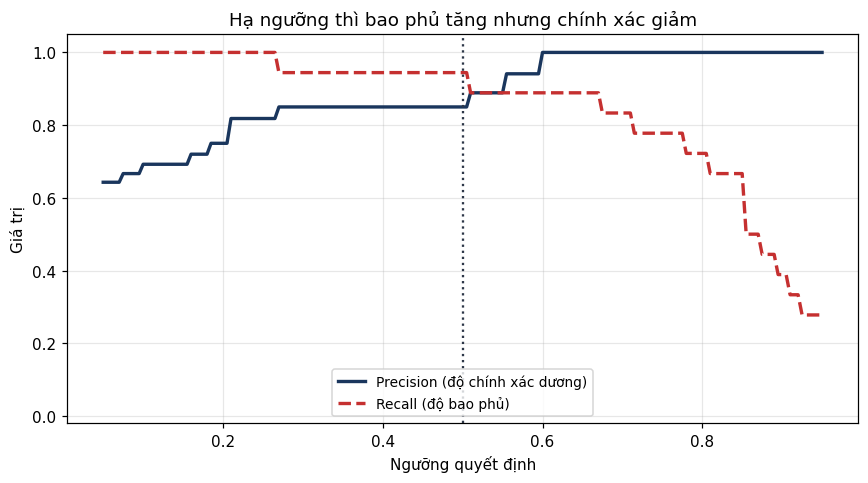

In [13]:
# Hình 6: precision và recall khi ngưỡng chạy từ 0.05 tới 0.95
cac_nguong_min = np.linspace(0.05, 0.95, 181)
ds_precision, ds_recall = [], []
for nguong in cac_nguong_min:
    nhan_theo_nguong = (p >= nguong).astype(int)
    ds_precision.append(precision_score(y_test, nhan_theo_nguong, zero_division=1))
    ds_recall.append(recall_score(y_test, nhan_theo_nguong, zero_division=0))

plt.figure(figsize=(8, 4.5))
plt.plot(cac_nguong_min, ds_precision, color="#1a365d", linewidth=2.2,
         label="Precision (độ chính xác dương)")
plt.plot(cac_nguong_min, ds_recall, "--", color="#c53030", linewidth=2.2,
         label="Recall (độ bao phủ)")
plt.axvline(0.5, linestyle=":", color="#2d3748")
plt.ylim(-0.02, 1.05)
plt.xlabel("Ngưỡng quyết định")
plt.ylabel("Giá trị")
plt.title("Hạ ngưỡng thì bao phủ tăng nhưng chính xác giảm")
plt.legend(loc="lower center", fontsize=9)
plt.tight_layout()
luu_hinh("hinh6_precision_recall_theo_nguong.png")

Bảng và hình cho thấy quy luật rất rõ:

- Ở ngưỡng **0.2**, mô hình gắn nhãn qua cho 24 bạn. Recall đạt 1.0000 — không bỏ sót bạn nào
  thật sự qua — nhưng precision chỉ còn 0.7500.
- Ở ngưỡng **0.5**, mô hình gắn nhãn qua cho 20 bạn. Precision 0.8500 và recall 0.9444.
- Ở ngưỡng **0.8**, mô hình chỉ còn gắn nhãn qua cho 13 bạn. Precision đạt 1.0000 — không báo nhầm
  bạn nào — nhưng recall tụt xuống 0.7222.

> **Quy luật phải nhớ:** **hạ ngưỡng** thì mô hình dễ tính hơn, gắn nhãn 1 cho nhiều người hơn,
> nên **recall tăng còn precision giảm**. **Nâng ngưỡng** thì ngược lại. Không có ngưỡng nào làm
> cả hai cùng tốt lên.

### Chọn ngưỡng theo bài toán *(Bảng 5)*

Vì không có ngưỡng tốt nhất một cách tuyệt đối, ta phải chọn theo cái giá phải trả của từng loại sai.

| Bài toán | Loại sai đắt hơn | Ngưỡng nên chọn |
|---|---|---|
| Cảnh báo sinh viên sắp rớt, nhãn 1 là qua môn | FP — báo một bạn sẽ qua trong khi bạn đó sắp rớt, nên bỏ sót mất | **Nâng** ngưỡng, cho mô hình khó gắn nhãn qua hơn |
| Sàng lọc một bệnh chữa được nếu phát hiện sớm, nhãn 1 là có bệnh | FN — bỏ sót một người có bệnh thật | **Hạ** ngưỡng, cho mô hình dễ báo bệnh hơn |
| Lọc thư rác và xoá thẳng, nhãn 1 là thư rác | FP — xoá nhầm một lá thư quan trọng | **Nâng** ngưỡng, thà để lọt thư rác còn hơn mất thư thật |

> **Câu hỏi phải tự trả lời trước khi chọn ngưỡng:** lớp tôi quan tâm là lớp nào, và sai kiểu nào
> đắt hơn? Cùng một ngưỡng cao có thể đúng ở bài này và sai ở bài kia, tùy nhãn 1 được đặt cho lớp nào.

---
## Bước 6 — Thêm biến đầu vào thứ hai *(Mục 7, `c6_hai_bien.py`)*

Kết quả cuối môn đâu chỉ phụ thuộc số giờ ôn. Điểm giữa kỳ cũng nói lên nhiều điều, vì nó phản
ánh cả quá trình học trước đó. Mô hình hai biến có dạng

$$\hat{y} = \sigma(w_1 x_1 + w_2 x_2 + b)$$

với $x_1$ là số giờ ôn và $x_2$ là điểm giữa kỳ. Trong mã **chỉ đổi đúng một chỗ**: danh sách
cột đưa vào `X`. Mọi dòng còn lại giữ nguyên — cái lợi của việc mọi mô hình scikit-learn dùng
chung một giao diện.

In [14]:
"""Bước 6: thêm điểm giữa kỳ làm biến thứ hai."""

y = df["qua_mon"]

# Chỉ đổi đúng một chỗ: danh sách cột đưa vào X
for ten, cot in [("Mot bien", ["gio_on"]),
                 ("Hai bien", ["gio_on", "diem_giua_ky"])]:
    X = df[cot]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=17, stratify=y
    )
    mo_hinh = LogisticRegression().fit(X_train, y_train)
    do_chinh_xac = accuracy_score(y_test, mo_hinh.predict(X_test))
    print(f"{ten}: accuracy tren tap kiem tra = {do_chinh_xac:.4f}")
print()

# Xem kỹ hệ số của mô hình hai biến
X = df[["gio_on", "diem_giua_ky"]]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
mo_hinh = LogisticRegression().fit(X_train, y_train)

print("He so cua tung bien:")
for ten_cot, he_so in zip(X.columns, mo_hinh.coef_[0]):
    print(f"  {ten_cot:14s} {he_so:+.4f}")
print(f"  {'he so chan':14s} {mo_hinh.intercept_[0]:+.4f}")
print()
print("Ca hai he so deu duong, nghia la on nhieu hon va")
print("diem giua ky cao hon deu lam tang xac suat qua mon.")

Mot bien: accuracy tren tap kiem tra = 0.8667
Hai bien: accuracy tren tap kiem tra = 0.9000

He so cua tung bien:
  gio_on         +0.3035
  diem_giua_ky   +0.5885
  he so chan     -6.9811

Ca hai he so deu duong, nghia la on nhieu hon va
diem giua ky cao hon deu lam tang xac suat qua mon.


**Đọc kết quả:** accuracy tăng từ **0.8667 lên 0.9000**. Mức tăng có thật nhưng không lớn, vì số
giờ ôn đã giải thích được phần lớn kết quả rồi. Trên 30 bạn kiểm tra, mô hình hai biến đoán đúng
thêm được **đúng 1 bạn** so với mô hình một biến.

> ⚠️ **Đừng vội mừng với mức tăng nhỏ.** Tập kiểm tra chỉ có 30 bạn, nên chênh lệch 1 bạn đã làm
> accuracy đổi hơn 3 phần trăm. Với cỡ mẫu nhỏ như vậy, mức tăng này chưa đủ để kết luận chắc chắn
> mô hình hai biến tốt hơn. Muốn chắc, phải chia dữ liệu nhiều lần rồi lấy trung bình — kỹ thuật
> **kiểm định chéo** (*cross validation*) ở các bài sau.

Hai hệ số đều dương: $w_1 = 0.3035$ cho số giờ ôn và $w_2 = 0.5885$ cho điểm giữa kỳ, khớp với
trực giác — ôn nhiều hơn và điểm giữa kỳ cao hơn đều làm tăng khả năng qua môn.

> ⚠️ **Đừng so độ lớn hai hệ số với nhau.** Nhìn qua rất dễ kết luận điểm giữa kỳ quan trọng gần
> gấp đôi số giờ ôn, vì 0.5885 gần gấp đôi 0.3035. Kết luận đó **không đúng**, vì hai biến có thang
> đo khác nhau hoàn toàn: số giờ ôn chạy từ 0 tới 29.5, còn điểm giữa kỳ chỉ từ 0 tới 10. Tăng một
> giờ ôn và tăng một điểm giữa kỳ là hai chuyện có độ khó rất khác nhau. Muốn so được thì phải đưa
> hai biến về cùng thang đo trước, bằng `StandardScaler` — nội dung của những bài sau.

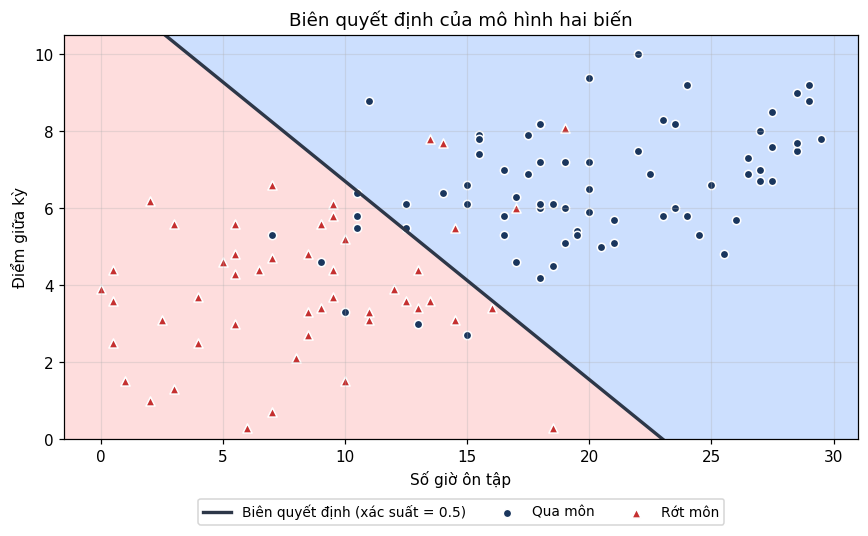

Phuong trinh bien: diem_giua_ky = -0.5157 * gio_on + 11.8620
Diem giua ky can co khi on 0 gio : 11.86
So gio on can co khi diem giua ky = 0: 23.00


In [15]:
# Hình 7: biên quyết định của mô hình hai biến
w1, w2 = mo_hinh.coef_[0]
b2 = mo_hinh.intercept_[0]

luoi_x1, luoi_x2 = np.meshgrid(np.linspace(-1.5, 31, 300), np.linspace(0, 10.5, 300))
luoi_diem = pd.DataFrame({"gio_on": luoi_x1.ravel(), "diem_giua_ky": luoi_x2.ravel()})
vung_du_doan = mo_hinh.predict(luoi_diem).reshape(luoi_x1.shape)

plt.figure()
plt.contourf(luoi_x1, luoi_x2, vung_du_doan, levels=[-0.5, 0.5, 1.5],
             colors=["#fed7d7", "#c3dafe"], alpha=0.85)
# Biên là tập các điểm có w1*x1 + w2*x2 + b = 0, rút x2 theo x1
x1_bien = np.linspace(-1.5, 31, 100)
plt.plot(x1_bien, -(w1 * x1_bien + b2) / w2, color="#2d3748", linewidth=2.2,
         label="Biên quyết định (xác suất = 0.5)")
plt.scatter(nhom_qua["gio_on"], nhom_qua["diem_giua_ky"], s=30, marker="o",
            color="#1a365d", edgecolor="white", label="Qua môn")
plt.scatter(nhom_rot["gio_on"], nhom_rot["diem_giua_ky"], s=36, marker="^",
            color="#c53030", edgecolor="white", label="Rớt môn")
plt.xlim(-1.5, 31)
plt.ylim(0, 10.5)
plt.xlabel("Số giờ ôn tập")
plt.ylabel("Điểm giữa kỳ")
plt.title("Biên quyết định của mô hình hai biến")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=3, fontsize=9)
plt.tight_layout()
luu_hinh("hinh7_bien_quyet_dinh_hai_bien.png")

print(f"Phuong trinh bien: diem_giua_ky = {-w1 / w2:.4f} * gio_on + {-b2 / w2:.4f}")
print(f"Diem giua ky can co khi on 0 gio : {-b2 / w2:.2f}")
print(f"So gio on can co khi diem giua ky = 0: {-b2 / w1:.2f}")

Vùng **xanh** là nơi mô hình đoán qua môn, vùng **hồng** là nơi mô hình đoán rớt. Ranh giới giữa
hai vùng là một **đường thẳng**, không phải đường cong. Tập hợp các điểm mà mô hình phân vân
đúng 50 phần trăm gọi là **biên quyết định** (*decision boundary*).

Phương trình biên cho thấy sự bù trừ giữa hai biến: điểm giữa kỳ càng cao thì số giờ ôn cần có để
được đoán qua càng ít, và ngược lại.

> **Biên quyết định của logistic luôn thẳng.** Với một biến đầu vào, biên là một **điểm** — chính
> là mốc 12.89 giờ ở Bước 3. Với hai biến, biên là một **đường thẳng** như trong hình. Với ba biến
> trở lên, biên là một **mặt phẳng**. Biên không bao giờ uốn cong: đó vừa là điểm mạnh (mô hình đơn
> giản, khó bị quá khớp), vừa là giới hạn (có những bộ dữ liệu mà một đường thẳng không tài nào
> chia được). Các bài sau sẽ giới thiệu những mô hình vẽ được biên cong.

---
# Phần B — Bài tập *(Mục 8)*

Sáu bài đều dùng đúng bộ dữ liệu `sinh_vien.csv` với 120 sinh viên ở trên.

**Tiêu chí chấm:** mã chạy được không lỗi, kết quả in ra đúng, có nhận xét bằng lời ở những bài
yêu cầu, và tên biến đặt có nghĩa. Riêng **bài 4 và bài 6 chấm nặng phần giải thích**, vì đó mới là
chỗ kiểm tra sinh viên có thật sự hiểu bốn thước đo hay không.

> 📌 **Lưu ý khi nộp bài:** thầy yêu cầu mỗi bài là **một tệp `.py` riêng** trong thư mục
> `baitap02` (`bai1.py` … `bai6.py`), chạy bằng `python baitap02/bai1.py` từ thư mục gốc.
> Notebook này dùng để làm và kiểm tra kết quả; khi nộp thì chép nội dung từng ô mã sang tệp
> `.py` tương ứng, thêm các dòng `import` ở đầu và để đường dẫn là `data/sinh_vien.csv`.

## Bài tập 1 — Thống kê theo nhóm

Đọc bộ dữ liệu rồi in ra ba con số: **số bạn có điểm giữa kỳ từ 7 trở lên**, **tỷ lệ qua môn của
riêng nhóm đó**, và **tỷ lệ qua môn của nhóm còn lại**. Nhận xét một câu về việc điểm giữa kỳ có
phân biệt được hai nhóm hay không.

In [16]:
"""Bai 1: thong ke ty le qua mon theo nhom diem giua ky."""

sinh_vien = pd.read_csv(DUONG_DAN)

nhom_diem_cao = sinh_vien[sinh_vien["diem_giua_ky"] >= 7]
nhom_con_lai = sinh_vien[sinh_vien["diem_giua_ky"] < 7]

so_ban_diem_cao = len(nhom_diem_cao)
ty_le_qua_diem_cao = nhom_diem_cao["qua_mon"].mean()
ty_le_qua_con_lai = nhom_con_lai["qua_mon"].mean()

print(f"So ban co diem giua ky tu 7 tro len : {so_ban_diem_cao}")
print(f"Ty le qua mon cua nhom do           : {ty_le_qua_diem_cao:.4f}")
print(f"Ty le qua mon cua nhom con lai      : {ty_le_qua_con_lai:.4f}"
      f"   ({len(nhom_con_lai)} ban)")
print()
print(f"De doi chieu, ty le qua mon ca lop  : {sinh_vien['qua_mon'].mean():.4f}")
print()

print("Chi tiet so ban qua / rot trong tung nhom:")
bang_nhom = pd.crosstab(
    np.where(sinh_vien["diem_giua_ky"] >= 7, "diem >= 7", "diem < 7"),
    sinh_vien["qua_mon"].map({0: "rot", 1: "qua"}),
    rownames=["nhom"], colnames=["ket_qua"],
)
print(bang_nhom.to_string())

So ban co diem giua ky tu 7 tro len : 31
Ty le qua mon cua nhom do           : 0.9032
Ty le qua mon cua nhom con lai      : 0.4831   (89 ban)

De doi chieu, ty le qua mon ca lop  : 0.5917

Chi tiet so ban qua / rot trong tung nhom:
ket_qua    qua  rot
nhom               
diem < 7    43   46
diem >= 7   28    3


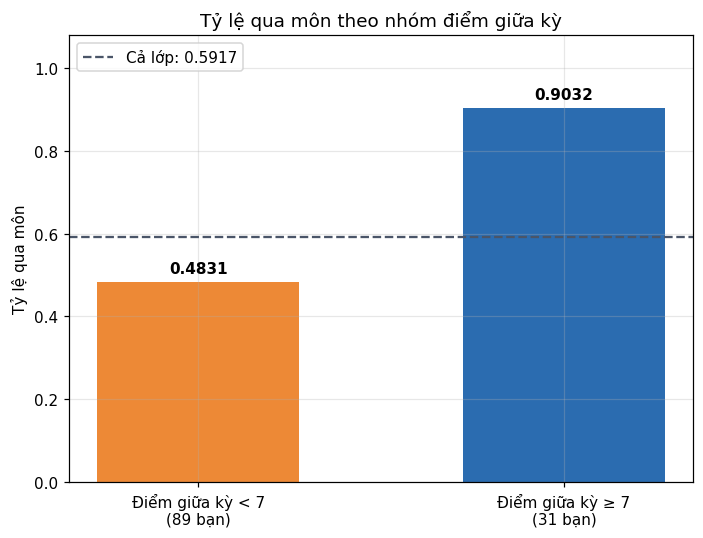

In [17]:
# Ve hai cot ty le qua mon de so sanh bang mat
ten_nhom = [f"Điểm giữa kỳ < 7\n({len(nhom_con_lai)} bạn)",
            f"Điểm giữa kỳ ≥ 7\n({so_ban_diem_cao} bạn)"]
ty_le_hai_nhom = [ty_le_qua_con_lai, ty_le_qua_diem_cao]

plt.figure(figsize=(6.5, 5))
cot_ve = plt.bar(ten_nhom, ty_le_hai_nhom, color=["#ed8936", MAU_QUA], width=0.55)
plt.bar_label(cot_ve, labels=[f"{t:.4f}" for t in ty_le_hai_nhom], padding=4, fontweight="bold")
plt.axhline(sinh_vien["qua_mon"].mean(), linestyle="--", color="#4a5568",
            label=f"Cả lớp: {sinh_vien['qua_mon'].mean():.4f}")
plt.ylim(0, 1.08)
plt.ylabel("Tỷ lệ qua môn")
plt.title("Tỷ lệ qua môn theo nhóm điểm giữa kỳ")
plt.legend(loc="upper left")
plt.tight_layout()
luu_hinh("bai1_ty_le_qua_mon_theo_nhom.png")

**Nhận xét:** có **31 bạn** đạt điểm giữa kỳ từ 7 trở lên, và **90.32%** trong số đó qua môn;
trong khi nhóm 89 bạn còn lại chỉ có **48.31%** qua môn — gần như tung đồng xu. Chênh lệch gần
**42 điểm phần trăm** cho thấy điểm giữa kỳ **phân biệt khá rõ** hai nhóm, nên đây là một đặc
trưng hữu ích — đúng với việc thêm `diem_giua_ky` ở Bước 6 đã làm accuracy tăng lên.

Tuy vậy, điểm giữa kỳ một mình chưa đủ: nhóm dưới 7 điểm vẫn có gần một nửa số bạn qua môn, nghĩa
là muốn đoán tốt cho nhóm này thì phải nhìn thêm số giờ ôn.

## Bài tập 2 — Vẽ hàm sigmoid

Vẽ đồ thị hàm sigmoid với $z$ chạy từ −8 tới 8, lưu thành tệp ảnh. Trên cùng hình, vẽ thêm một
đường ngang tại mức 0.5 và một đường dọc tại $z = 0$.

> Đề yêu cầu lưu thành `sigmoid.png`. Trong notebook này ảnh được gom vào thư mục `images/` với
> tên `bai2_sigmoid.png` cho cùng kiểu với các hình khác; khi nộp tệp `bai2.py` thì đổi lại
> thành `plt.savefig("sigmoid.png")`.

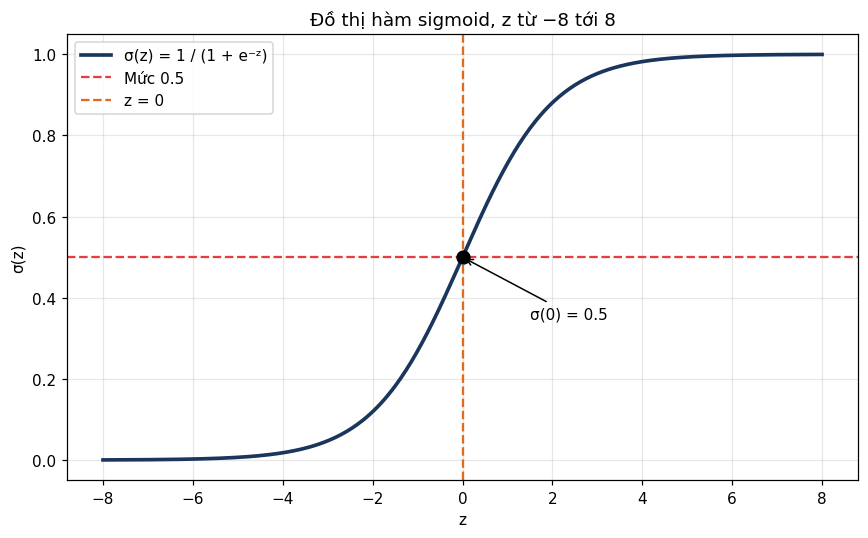

Da luu hinh ra tep images/bai2_sigmoid.png

Kiem tra nhanh: sigmoid(-8) = 0.0003, sigmoid(0) = 0.5000, sigmoid(8) = 0.9997


In [18]:
"""Bai 2: ve do thi ham sigmoid, luu ra tep anh."""


def ham_sigmoid(z):
    """Ep mot so thuc bat ky ve khoang tu 0 toi 1."""
    return 1 / (1 + np.exp(-z))


truc_z = np.linspace(-8, 8, 400)
gia_tri_sigmoid = ham_sigmoid(truc_z)

plt.figure()
plt.plot(truc_z, gia_tri_sigmoid, color="#1a365d", linewidth=2.4, label="σ(z) = 1 / (1 + e⁻ᶻ)")
plt.axhline(0.5, color=MAU_ROT, linestyle="--", linewidth=1.5, label="Mức 0.5")
plt.axvline(0, color="#dd6b20", linestyle="--", linewidth=1.5, label="z = 0")
plt.scatter([0], [ham_sigmoid(0)], s=70, color="black", zorder=5)
plt.annotate(f"σ(0) = {ham_sigmoid(0):.1f}", xy=(0, 0.5), xytext=(1.5, 0.35),
             arrowprops=dict(arrowstyle="->", color="black"))
plt.xlabel("z")
plt.ylabel("σ(z)")
plt.title("Đồ thị hàm sigmoid, z từ −8 tới 8")
plt.legend(loc="upper left")
plt.tight_layout()
luu_hinh("bai2_sigmoid.png")   # luu TRUOC khi show

print("Da luu hinh ra tep images/bai2_sigmoid.png")
print()
print(f"Kiem tra nhanh: sigmoid(-8) = {ham_sigmoid(-8):.4f}, "
      f"sigmoid(0) = {ham_sigmoid(0):.4f}, sigmoid(8) = {ham_sigmoid(8):.4f}")

Hai đường phụ cắt nhau đúng tại điểm $(0,\ 0.5)$ nằm trên đường cong — cách tự kiểm chứng rằng
hàm được viết đúng dấu. Nếu lỡ viết `np.exp(z)` thì đường cong vẫn đi qua điểm đó nhưng **lật
ngược**, đi xuống từ trái sang phải; nhìn hình là phát hiện ngay.

## Bài tập 3 — Dự đoán cho một bạn cụ thể

Khớp lại mô hình một biến như ở Bước 3, rồi viết một hàm `du_doan(gio)` nhận vào số giờ ôn và in
ra ba thứ: **giá trị $z$**, **xác suất qua môn**, và **nhãn theo ngưỡng 0.5**. Gọi hàm với các giá trị
3, 8, 12.89, 18 và 26 giờ. Giải thích vì sao với 12.89 giờ thì xác suất ra gần đúng 0.5.

In [19]:
"""Bai 3: ham du_doan(gio) in ra z, xac suat qua mon va nhan theo nguong 0.5."""

from sklearn.linear_model import LogisticRegression

sinh_vien = pd.read_csv(DUONG_DAN)
mo_hinh_mot_bien = LogisticRegression().fit(sinh_vien[["gio_on"]], sinh_vien["qua_mon"])

HE_SO_GOC = float(mo_hinh_mot_bien.coef_[0][0])
HE_SO_CHAN = float(mo_hinh_mot_bien.intercept_[0])
NGUONG = 0.5


def du_doan(gio):
    """Tinh z = w*gio + b, boc sigmoid ra xac suat, roi so voi nguong de ra nhan."""
    z = HE_SO_GOC * gio + HE_SO_CHAN
    xac_suat_qua = 1 / (1 + np.exp(-z))
    nhan = 1 if xac_suat_qua >= NGUONG else 0
    print(f"  {gio:6.2f} gio | z = {z:+8.4f} | xac suat qua = {xac_suat_qua:.4f}"
          f" | nhan = {nhan} ({'qua' if nhan == 1 else 'rot'})")
    return z, xac_suat_qua, nhan


print(f"Mo hinh: z = {HE_SO_GOC:.6f} * gio + ({HE_SO_CHAN:.6f})")
print(f"Moc xac suat 0.5 nam tai -b / w = {-HE_SO_CHAN / HE_SO_GOC:.4f} gio")
print()

cac_gio_thu = [3, 8, 12.89, 18, 26]
ket_qua_du_doan = [du_doan(gio) for gio in cac_gio_thu]
print()

# Doi chieu voi predict_proba cua thu vien, hai ben phai trung nhau
xac_suat_thu_vien = mo_hinh_mot_bien.predict_proba(pd.DataFrame({"gio_on": cac_gio_thu}))[:, 1]
xac_suat_tu_tinh = np.array([kq[1] for kq in ket_qua_du_doan])
print("Xac suat tu tinh trung voi predict_proba:", np.allclose(xac_suat_tu_tinh, xac_suat_thu_vien))

Mo hinh: z = 0.392819 * gio + (-5.064890)
Moc xac suat 0.5 nam tai -b / w = 12.8937 gio

    3.00 gio | z =  -3.8864 | xac suat qua = 0.0201 | nhan = 0 (rot)
    8.00 gio | z =  -1.9223 | xac suat qua = 0.1276 | nhan = 0 (rot)
   12.89 gio | z =  -0.0015 | xac suat qua = 0.4996 | nhan = 0 (rot)
   18.00 gio | z =  +2.0059 | xac suat qua = 0.8814 | nhan = 1 (qua)
   26.00 gio | z =  +5.1484 | xac suat qua = 0.9942 | nhan = 1 (qua)

Xac suat tu tinh trung voi predict_proba: True


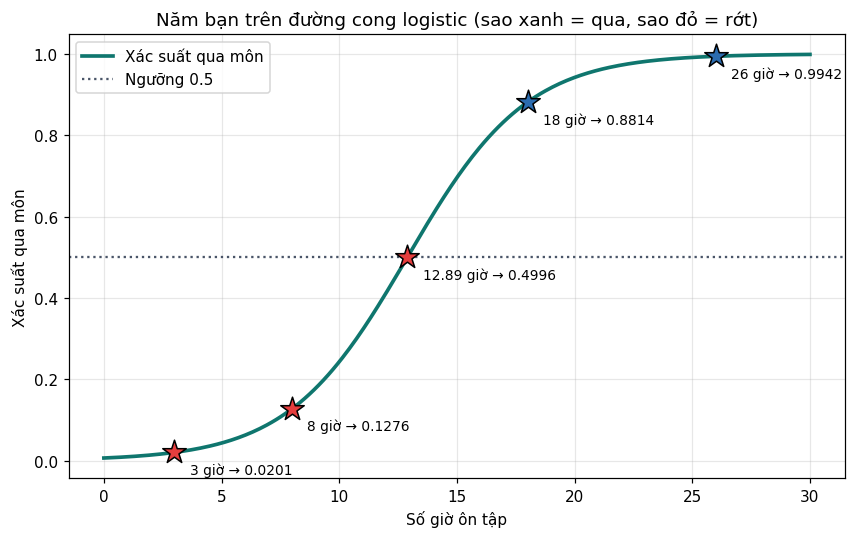

In [20]:
# Dat nam ban len duong cong de thay vi tri cua tung ban
luoi_gio_bai3 = np.linspace(0, 30, 300)
duong_cong = 1 / (1 + np.exp(-(HE_SO_GOC * luoi_gio_bai3 + HE_SO_CHAN)))

plt.figure()
plt.plot(luoi_gio_bai3, duong_cong, color="#0f766e", linewidth=2.4,
         label="Xác suất qua môn")
plt.axhline(NGUONG, linestyle=":", color="#4a5568", label="Ngưỡng 0.5")
for gio, (z, xac_suat_qua, nhan) in zip(cac_gio_thu, ket_qua_du_doan):
    plt.scatter([gio], [xac_suat_qua], marker="*", s=260, zorder=5, edgecolor="black",
                color=MAU_QUA if nhan == 1 else MAU_ROT)
    plt.annotate(f"{gio} giờ → {xac_suat_qua:.4f}", (gio, xac_suat_qua),
                 textcoords="offset points", xytext=(10, -14), fontsize=9)
plt.xlabel("Số giờ ôn tập")
plt.ylabel("Xác suất qua môn")
plt.title("Năm bạn trên đường cong logistic (sao xanh = qua, sao đỏ = rớt)")
plt.legend(loc="upper left")
plt.tight_layout()
luu_hinh("bai3_du_doan_nam_ban.png")

**Vì sao 12.89 giờ cho xác suất gần đúng 0.5:** xác suất bằng 0.5 khi và chỉ khi $z = 0$, vì
$\sigma(0) = 1/(1+e^0) = 1/2$. Giải $z = wx + b = 0$ được $x = -b/w = 5.064890 / 0.392819 \approx
12.8937$ giờ — đây chính là mốc "năm mươi năm mươi" tìm được ở Bước 3. Số 12.89 là mốc đó đã làm
tròn, nên $z$ gần bằng 0 (chỉ khoảng −0.0015) và xác suất ra gần đúng 0.5.

**Một chi tiết đáng chú ý:** vì 12.89 **nhỏ hơn một chút** so với mốc thật 12.8937, $z$ hơi âm và
xác suất là 0.4996, thấp hơn 0.5 một chút xíu — nên nhãn theo ngưỡng 0.5 ra **0 (rớt)**. Ngay tại
biên quyết định, chênh lệch vài phần nghìn giờ cũng đủ lật nhãn; đó là lý do một bạn nằm sát mốc
thì con số xác suất có ý nghĩa hơn nhiều so với cái nhãn 0 hay 1.

Các bạn còn lại hợp lý: 3 và 8 giờ nằm xa dưới mốc nên gần như chắc rớt, 18 và 26 giờ nằm xa trên
mốc nên gần như chắc qua.

## Bài tập 4 — Tự tính bốn thước đo

Chép tệp `c4_danh_gia.py` sang `baitap02` rồi **bỏ hết** các hàm `accuracy_score`,
`precision_score`, `recall_score`, `f1_score` của scikit-learn. Tự tính bốn con số đó chỉ từ bốn số
TP, TN, FP, FN bằng công thức ở Bước 4, rồi so với kết quả thư viện in ra trong tài liệu — hai bên
phải khớp.

In [21]:
"""Bai 4: tu tinh accuracy, precision, recall, F1 chi tu bon so TP, TN, FP, FN."""

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix      # chi giu lai ham nay, bo het bon ham tinh diem
from sklearn.model_selection import train_test_split

sinh_vien = pd.read_csv(DUONG_DAN)
X = sinh_vien[["gio_on"]]
y = sinh_vien["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
mo_hinh_bai4 = LogisticRegression().fit(X_train, y_train)
nhan_du_doan = mo_hinh_bai4.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, nhan_du_doan).ravel()

# Dem lai bon o bang tay de chac chan hieu dung y nghia tung o
nhan_that = y_test.to_numpy()
tp_dem_tay = int(((nhan_du_doan == 1) & (nhan_that == 1)).sum())
tn_dem_tay = int(((nhan_du_doan == 0) & (nhan_that == 0)).sum())
fp_dem_tay = int(((nhan_du_doan == 1) & (nhan_that == 0)).sum())
fn_dem_tay = int(((nhan_du_doan == 0) & (nhan_that == 1)).sum())

print("Bon o cua ma tran nham lan (confusion_matrix / dem tay):")
print(f"  TP = {tp:2d} / {tp_dem_tay:2d}   doan qua, that su qua")
print(f"  TN = {tn:2d} / {tn_dem_tay:2d}   doan rot, that su rot")
print(f"  FP = {fp:2d} / {fp_dem_tay:2d}   doan qua, that ra rot")
print(f"  FN = {fn:2d} / {fn_dem_tay:2d}   doan rot, that ra qua")
print()

tong_so_ban = tp + tn + fp + fn
accuracy_tu_tinh = (tp + tn) / tong_so_ban
precision_tu_tinh = tp / (tp + fp)
recall_tu_tinh = tp / (tp + fn)
f1_tu_tinh = 2 * precision_tu_tinh * recall_tu_tinh / (precision_tu_tinh + recall_tu_tinh)

print("Tu tinh bang cong thuc:")
print(f"  Accuracy  = (TP + TN) / tong  = ({tp} + {tn}) / {tong_so_ban}"
      f" = {accuracy_tu_tinh:.4f}")
print(f"  Precision = TP / (TP + FP)    = {tp} / ({tp} + {fp})"
      f" = {precision_tu_tinh:.4f}")
print(f"  Recall    = TP / (TP + FN)    = {tp} / ({tp} + {fn})"
      f" = {recall_tu_tinh:.4f}")
print(f"  F1        = 2*P*R / (P + R)   = 2*{precision_tu_tinh:.4f}*{recall_tu_tinh:.4f}"
      f" / ({precision_tu_tinh:.4f} + {recall_tu_tinh:.4f}) = {f1_tu_tinh:.4f}")
print()

# Ket qua thu vien in ra trong tai lieu (Muc 5.2)
ket_qua_tai_lieu = {"Accuracy": 0.8667, "Precision": 0.8500, "Recall": 0.9444, "F1": 0.8947}
ket_qua_tu_tinh = {"Accuracy": accuracy_tu_tinh, "Precision": precision_tu_tinh,
                   "Recall": recall_tu_tinh, "F1": f1_tu_tinh}

print(f"{'Thuoc do':10s} | {'Tu tinh':>8s} | {'Tai lieu':>8s} | Khop?")
print("-" * 42)
for ten_thuoc_do, gia_tri_tai_lieu in ket_qua_tai_lieu.items():
    gia_tri_tu_tinh = ket_qua_tu_tinh[ten_thuoc_do]
    khop = "co" if round(gia_tri_tu_tinh, 4) == gia_tri_tai_lieu else "KHONG"
    print(f"{ten_thuoc_do:10s} | {gia_tri_tu_tinh:8.4f} | {gia_tri_tai_lieu:8.4f} | {khop}")

Bon o cua ma tran nham lan (confusion_matrix / dem tay):
  TP = 17 / 17   doan qua, that su qua
  TN =  9 /  9   doan rot, that su rot
  FP =  3 /  3   doan qua, that ra rot
  FN =  1 /  1   doan rot, that ra qua

Tu tinh bang cong thuc:
  Accuracy  = (TP + TN) / tong  = (17 + 9) / 30 = 0.8667
  Precision = TP / (TP + FP)    = 17 / (17 + 3) = 0.8500
  Recall    = TP / (TP + FN)    = 17 / (17 + 1) = 0.9444
  F1        = 2*P*R / (P + R)   = 2*0.8500*0.9444 / (0.8500 + 0.9444) = 0.8947

Thuoc do   |  Tu tinh | Tai lieu | Khop?
------------------------------------------
Accuracy   |   0.8667 |   0.8667 | co
Precision  |   0.8500 |   0.8500 | co
Recall     |   0.9444 |   0.9444 | co
F1         |   0.8947 |   0.8947 | co


**Kết quả:** cả bốn con số tự tính đều **khớp tới chữ số thứ tư** với kết quả thư viện in ra trong
tài liệu. Đếm tay bốn ô bằng phép so sánh mảng cũng ra đúng TP = 17, TN = 9, FP = 3, FN = 1 như
`confusion_matrix`, chứng tỏ đã hiểu đúng thứ tự `tn, fp, fn, tp` mà scikit-learn trả về.

**Giải thích từng thước đo:**

- **Accuracy = (17 + 9) / 30 = 0.8667.** Tử số là hai ô đoán đúng (đoán qua và qua thật, đoán rớt và
  rớt thật), mẫu số là toàn bộ 30 bạn. Đây là tỷ lệ đoán đúng chung, **không phân biệt** đoán sai
  kiểu nào.
- **Precision = 17 / (17 + 3) = 0.8500.** Mẫu số là **20 bạn mà mô hình nói sẽ qua** (TP + FP). Trả
  lời câu hỏi: *khi mô hình nói "qua", nó đúng bao nhiêu phần?* 3 bạn FP — thật ra rớt nhưng bị đoán
  qua — là thứ kéo precision xuống.
- **Recall = 17 / (17 + 1) = 0.9444.** Mẫu số là **18 bạn thật sự qua môn** (TP + FN). Trả lời câu hỏi:
  *trong số các bạn thật sự qua, mô hình tìm ra được bao nhiêu phần?* Chỉ 1 bạn FN bị bỏ sót nên
  recall cao.
- **F1 = 2 × 0.85 × 0.9444 / (0.85 + 0.9444) = 0.8947.** Là **trung bình điều hòa** của precision và
  recall, không phải trung bình cộng (trung bình cộng sẽ là 0.8972). Trung bình điều hòa bị kéo về
  phía con số nhỏ hơn, nên F1 chỉ cao khi **cả hai** cùng cao — mô hình không thể "ăn gian" bằng cách
  đẩy một thước đo lên 1 và bỏ mặc thước đo kia.

Điều rút ra được khi tự tính: **precision và recall có cùng tử số TP, chỉ khác mẫu số.** FP chỉ xuất
hiện trong precision, FN chỉ xuất hiện trong recall — nên hai loại sai ảnh hưởng tới hai con số khác
nhau, và accuracy (gộp chung hai loại sai) không cho biết mô hình đang sai theo kiểu nào.

## Bài tập 5 — Dò ngưỡng tốt nhất theo $F_1$

Cho ngưỡng chạy từ 0.05 tới 0.95, mỗi bước 0.05. Với mỗi ngưỡng, tính $F_1$ trên tập kiểm tra rồi
in ra thành bảng. Cuối cùng in ra ngưỡng cho $F_1$ cao nhất, và nhận xét: ngưỡng tốt nhất theo $F_1$
có đúng bằng 0.5 không?

In [22]:
"""Bai 5: do nguong tu 0.05 toi 0.95, tim nguong cho F1 cao nhat tren tap kiem tra."""

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split

sinh_vien = pd.read_csv(DUONG_DAN)
X = sinh_vien[["gio_on"]]
y = sinh_vien["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
mo_hinh_bai5 = LogisticRegression().fit(X_train, y_train)
xac_suat_qua = mo_hinh_bai5.predict_proba(X_test)[:, 1]

# Lam tron de 0.15000000000000002 hien thi va so sanh gon gang thanh 0.15
cac_nguong = np.round(np.arange(0.05, 1.0, 0.05), 2)
ds_f1 = []

print("Nguong | Doan la qua | Precision | Recall |   F1")
print("-" * 50)
for nguong in cac_nguong:
    nhan_theo_nguong = (xac_suat_qua >= nguong).astype(int)
    f1 = f1_score(y_test, nhan_theo_nguong, zero_division=0)
    pre = precision_score(y_test, nhan_theo_nguong, zero_division=0)
    rec = recall_score(y_test, nhan_theo_nguong, zero_division=0)
    ds_f1.append(f1)
    print(f" {nguong:.2f}  |     {nhan_theo_nguong.sum():2d}      |  {pre:.4f}   | {rec:.4f} | {f1:.4f}")
print()

ds_f1 = np.array(ds_f1)
vi_tri_tot_nhat = int(np.argmax(ds_f1))
nguong_tot_nhat = cac_nguong[vi_tri_tot_nhat]
f1_cao_nhat = ds_f1[vi_tri_tot_nhat]
cac_nguong_hoa = cac_nguong[np.isclose(ds_f1, f1_cao_nhat)]
f1_tai_05 = ds_f1[np.isclose(cac_nguong, 0.5)][0]

print(f"Nguong cho F1 cao nhat: {nguong_tot_nhat:.2f}  (F1 = {f1_cao_nhat:.4f})")
print(f"Cac nguong cung dat F1 cao nhat: {', '.join(f'{t:.2f}' for t in cac_nguong_hoa)}")
print(f"F1 tai nguong mac dinh 0.50   : {f1_tai_05:.4f}")

Nguong | Doan la qua | Precision | Recall |   F1
--------------------------------------------------
 0.05  |     28      |  0.6429   | 1.0000 | 0.7826
 0.10  |     26      |  0.6923   | 1.0000 | 0.8182
 0.15  |     26      |  0.6923   | 1.0000 | 0.8182
 0.20  |     24      |  0.7500   | 1.0000 | 0.8571
 0.25  |     22      |  0.8182   | 1.0000 | 0.9000
 0.30  |     20      |  0.8500   | 0.9444 | 0.8947
 0.35  |     20      |  0.8500   | 0.9444 | 0.8947
 0.40  |     20      |  0.8500   | 0.9444 | 0.8947
 0.45  |     20      |  0.8500   | 0.9444 | 0.8947
 0.50  |     20      |  0.8500   | 0.9444 | 0.8947
 0.55  |     18      |  0.8889   | 0.8889 | 0.8889
 0.60  |     16      |  1.0000   | 0.8889 | 0.9412
 0.65  |     16      |  1.0000   | 0.8889 | 0.9412


 0.70  |     15      |  1.0000   | 0.8333 | 0.9091
 0.75  |     14      |  1.0000   | 0.7778 | 0.8750
 0.80  |     13      |  1.0000   | 0.7222 | 0.8387


 0.85  |     12      |  1.0000   | 0.6667 | 0.8000
 0.90  |      7      |  1.0000   | 0.3889 | 0.5600
 0.95  |      5      |  1.0000   | 0.2778 | 0.4348

Nguong cho F1 cao nhat: 0.60  (F1 = 0.9412)
Cac nguong cung dat F1 cao nhat: 0.60, 0.65
F1 tai nguong mac dinh 0.50   : 0.8947


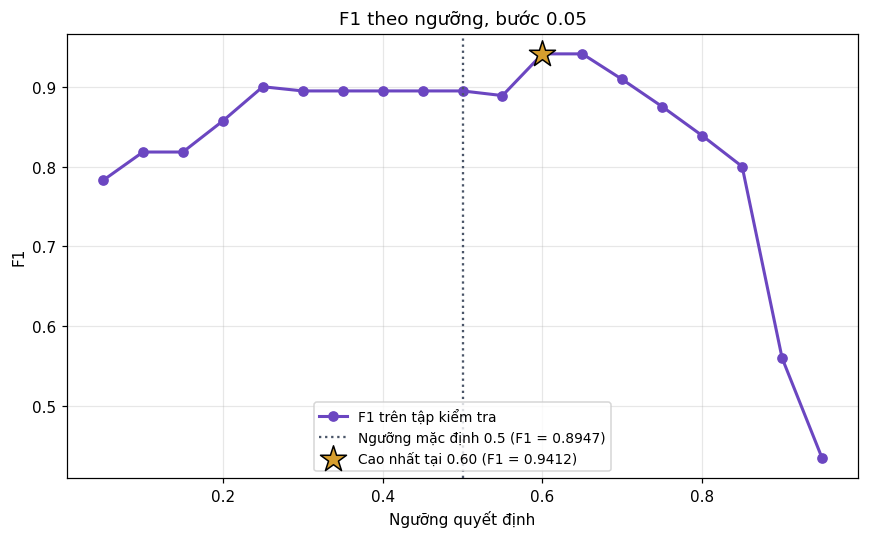

In [23]:
plt.figure()
plt.plot(cac_nguong, ds_f1, marker="o", color="#6b46c1", linewidth=2, label="F1 trên tập kiểm tra")
plt.axvline(0.5, linestyle=":", color="#4a5568", label=f"Ngưỡng mặc định 0.5 (F1 = {f1_tai_05:.4f})")
plt.scatter([nguong_tot_nhat], [f1_cao_nhat], marker="*", s=320, color="#d69e2e",
            edgecolor="black", zorder=5,
            label=f"Cao nhất tại {nguong_tot_nhat:.2f} (F1 = {f1_cao_nhat:.4f})")
plt.xlabel("Ngưỡng quyết định")
plt.ylabel("F1")
plt.title("F1 theo ngưỡng, bước 0.05")
plt.legend(loc="lower center", fontsize=9)
plt.tight_layout()
luu_hinh("bai5_f1_theo_nguong.png")

**Nhận xét:** ngưỡng tốt nhất theo $F_1$ **không phải 0.5** mà là **0.60** ($F_1$ = 0.9412, ngưỡng
0.65 cũng hòa ở cùng mức), cao hơn $F_1$ = 0.8947 ở ngưỡng mặc định. Ở ngưỡng 0.60 mô hình khó tính
hơn một chút: 3 bạn FP (thật ra rớt nhưng có xác suất trong khoảng 0.5 – 0.6) rơi về phía rớt nên
precision lên 1.0000, trong khi chỉ mất thêm 1 bạn qua thật nên recall còn 0.8889 — đổi được như vậy
là lời.

Nhưng không nên vội đổi ngưỡng mặc định thành 0.60, vì hai lẽ:

1. Ngưỡng này được **chọn trên chính tập kiểm tra** — giống như xem đề rồi mới chọn cách làm bài,
   nên $F_1$ = 0.9412 là con số lạc quan hơn thực tế. Cách làm đúng là chọn ngưỡng trên một phần
   dữ liệu riêng (tập kiểm định) hoặc bằng kiểm định chéo, rồi mới chấm trên tập kiểm tra.
2. Tập kiểm tra chỉ có 30 bạn, mỗi bạn đổi nhãn là $F_1$ đổi vài phần trăm; ngưỡng "tốt nhất" có thể
   dịch chuyển nếu đổi `random_state`.

Ngoài ra, $F_1$ coi precision và recall quan trọng như nhau. Nếu bài toán thật đặt nặng một loại sai
hơn (như Bảng 5 ở Bước 5) thì ngưỡng nên chọn theo cái giá của loại sai đó, không nhất thiết theo $F_1$.

## Bài tập 6 — Đổi lớp dương rồi chấm lại

Ở Bước 4 ta luôn lấy lớp dương là qua môn. Bây giờ hãy chấm điểm cho **lớp rớt môn**, tức lớp 0,
bằng cách thêm tham số `pos_label=0` vào `precision_score` và `recall_score`. In precision và recall
của lớp 0 rồi so với con số của lớp 1. Giải thích bằng lời vì sao hai bộ số khác nhau, dù mô hình và
dữ liệu không đổi chút nào.

In [24]:
"""Bai 6: cham diem cho lop rot mon (pos_label=0) va so voi lop qua mon."""

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_score, recall_score)
from sklearn.model_selection import train_test_split

sinh_vien = pd.read_csv(DUONG_DAN)
X = sinh_vien[["gio_on"]]
y = sinh_vien["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
mo_hinh_bai6 = LogisticRegression().fit(X_train, y_train)
nhan_du_doan = mo_hinh_bai6.predict(X_test)

# Lop duong = 1 (qua mon), mac dinh cua scikit-learn
precision_lop_qua = precision_score(y_test, nhan_du_doan)
recall_lop_qua = recall_score(y_test, nhan_du_doan)

# Lop duong = 0 (rot mon)
precision_lop_rot = precision_score(y_test, nhan_du_doan, pos_label=0)
recall_lop_rot = recall_score(y_test, nhan_du_doan, pos_label=0)

tn, fp, fn, tp = confusion_matrix(y_test, nhan_du_doan).ravel()

print(f"{'Lop duong':18s} | {'Precision':>9s} | {'Recall':>7s}")
print("-" * 42)
print(f"{'1 = qua mon':18s} | {precision_lop_qua:9.4f} | {recall_lop_qua:7.4f}")
print(f"{'0 = rot mon':18s} | {precision_lop_rot:9.4f} | {recall_lop_rot:7.4f}")
print()

print("Cung mot ma tran nham lan: TN = %d, FP = %d, FN = %d, TP = %d" % (tn, fp, fn, tp))
print()
print("Lop 1 (qua mon):")
print(f"  Precision = TP / (TP + FP) = {tp} / ({tp} + {fp}) = {tp / (tp + fp):.4f}")
print(f"  Recall    = TP / (TP + FN) = {tp} / ({tp} + {fn}) = {tp / (tp + fn):.4f}")
print("Lop 0 (rot mon) - vai tro hai lop doi cho nhau:")
print(f"  Precision = TN / (TN + FN) = {tn} / ({tn} + {fn}) = {tn / (tn + fn):.4f}")
print(f"  Recall    = TN / (TN + FP) = {tn} / ({tn} + {fp}) = {tn / (tn + fp):.4f}")
print()

print("Doi chieu bang classification_report:")
print(classification_report(y_test, nhan_du_doan, target_names=["rot (0)", "qua (1)"], digits=4))

Lop duong          | Precision |  Recall
------------------------------------------
1 = qua mon        |    0.8500 |  0.9444
0 = rot mon        |    0.9000 |  0.7500

Cung mot ma tran nham lan: TN = 9, FP = 3, FN = 1, TP = 17

Lop 1 (qua mon):
  Precision = TP / (TP + FP) = 17 / (17 + 3) = 0.8500
  Recall    = TP / (TP + FN) = 17 / (17 + 1) = 0.9444
Lop 0 (rot mon) - vai tro hai lop doi cho nhau:
  Precision = TN / (TN + FN) = 9 / (9 + 1) = 0.9000
  Recall    = TN / (TN + FP) = 9 / (9 + 3) = 0.7500

Doi chieu bang classification_report:
              precision    recall  f1-score   support

     rot (0)     0.9000    0.7500    0.8182        12
     qua (1)     0.8500    0.9444    0.8947        18

    accuracy                         0.8667        30
   macro avg     0.8750    0.8472    0.8565        30
weighted avg     0.8700    0.8667    0.8641        30



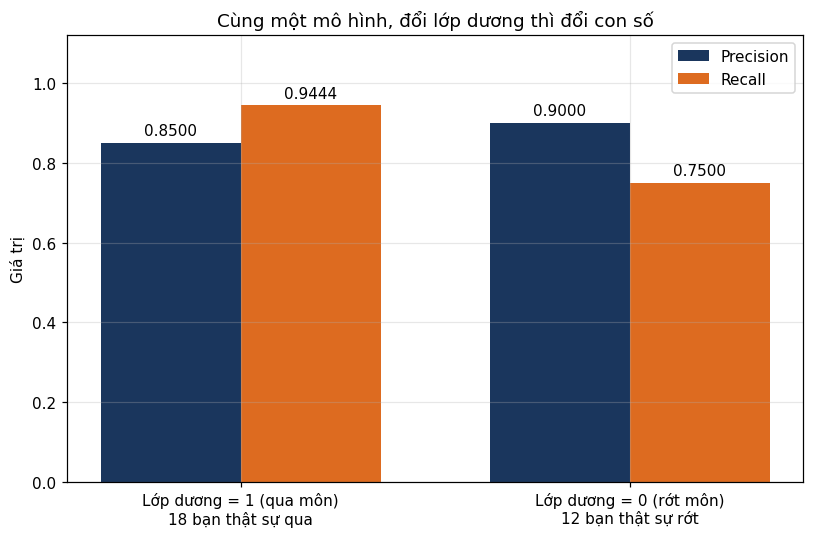

In [25]:
# So sanh hai bo so bang bieu do cot doi
vi_tri = np.arange(2)
do_rong = 0.36

fig, ax = plt.subplots(figsize=(7.5, 5))
cot_pre = ax.bar(vi_tri - do_rong / 2, [precision_lop_qua, precision_lop_rot], do_rong,
                 color="#1a365d", label="Precision")
cot_rec = ax.bar(vi_tri + do_rong / 2, [recall_lop_qua, recall_lop_rot], do_rong,
                 color="#dd6b20", label="Recall")
ax.bar_label(cot_pre, fmt="%.4f", padding=3)
ax.bar_label(cot_rec, fmt="%.4f", padding=3)
ax.set_xticks(vi_tri, [f"Lớp dương = 1 (qua môn)\n{tp + fn} bạn thật sự qua",
                       f"Lớp dương = 0 (rớt môn)\n{tn + fp} bạn thật sự rớt"])
ax.set_ylim(0, 1.12)
ax.set_ylabel("Giá trị")
ax.set_title("Cùng một mô hình, đổi lớp dương thì đổi con số")
ax.legend(loc="upper right")
plt.tight_layout()
luu_hinh("bai6_so_sanh_hai_lop_duong.png")

**Kết quả:**

| Lớp dương | Precision | Recall |
|---|---|---|
| 1 = qua môn | 0.8500 | 0.9444 |
| 0 = rớt môn | **0.9000** | **0.7500** |

**Vì sao hai bộ số khác nhau dù mô hình và dữ liệu không đổi:** ma trận nhầm lẫn vẫn là một —
TN = 9, FP = 3, FN = 1, TP = 17. Điều thay đổi là **vai trò của từng ô**. Khi đổi lớp dương sang 0,
"đoán đúng lớp dương" giờ là 9 bạn rớt được đoán rớt (ô TN cũ), và hai loại sai **đổi chỗ cho nhau**:

- **3 bạn thật ra rớt nhưng bị đoán qua.** Với lớp 1, đây là lỗi *báo nhầm* (FP) nên kéo **precision**
  của lớp 1 xuống: 17/20 = 0.85. Với lớp 0, đây lại là những bạn rớt mà mô hình **bỏ sót**, nên kéo
  **recall** của lớp 0 xuống: chỉ tìm ra 9 trong 12 bạn rớt, 9/12 = 0.75.
- **1 bạn thật ra qua nhưng bị đoán rớt.** Với lớp 1, đây là bạn bị bỏ sót nên chỉ làm recall lớp 1
  giảm nhẹ: 17/18 = 0.9444. Với lớp 0, đây là lỗi báo nhầm nên làm precision lớp 0 giảm nhẹ:
  9/10 = 0.90.

Thêm vào đó, hai lớp có kích thước khác nhau trong tập kiểm tra (18 bạn qua, 12 bạn rớt): cùng 3 bạn
sai, nhưng chia cho 12 thì "đau" hơn chia cho 20, nên con số của lớp nhỏ hơn dao động mạnh hơn.

**Ý nghĩa thực tế:** bài toán ở đầu bài là *giảng viên muốn tìm những bạn sắp rớt để nhắc nhở*. Với
mục đích đó, con số cần nhìn là **recall của lớp rớt môn = 0.75**: mô hình bỏ sót **1/4** số bạn cần
cảnh báo. Nếu chỉ báo cáo "recall = 0.9444" của lớp qua môn thì nghe rất tốt nhưng che mất đúng điểm
yếu quan trọng nhất. Đây chính là lời nhắc ở Bước 4: **mỗi lần báo cáo một con số, luôn phải nói rõ
đang tính cho lớp nào.** Muốn bắt thêm các bạn sắp rớt thì nên **nâng ngưỡng** gắn nhãn qua (như Bảng 5
gợi ý), chấp nhận precision của lớp rớt giảm đi một chút.

---
## Tổng kết — các con số chính của bài *(Bảng 8)*

| Đại lượng | Giá trị | Ở đâu |
|---|---|---|
| Số sinh viên trong bộ dữ liệu | 120, gồm 71 qua và 49 rớt | Bước 1 |
| Số giờ ôn trung bình, nhóm rớt và nhóm qua | 8.29 và 19.89 giờ | Bước 1 |
| Hệ số của mô hình một biến | $w = 0.392819$, $b = -5.064890$ | Bước 3 |
| Số giờ ôn ứng với xác suất 0.5 | 12.89 giờ | Bước 3, Bài tập 3 |
| Chia dữ liệu | 90 để học, 30 để kiểm tra | Bước 4 |
| Ma trận nhầm lẫn | TP = 17, TN = 9, FP = 3, FN = 1 | Bước 4, Bài tập 4 |
| Accuracy, Precision | 0.8667 và 0.8500 | Bước 4, Bài tập 4 |
| Recall, $F_1$ | 0.9444 và 0.8947 | Bước 4, Bài tập 4 |
| Precision, Recall của lớp rớt môn | 0.9000 và 0.7500 | Bài tập 6 |
| Ngưỡng cho $F_1$ cao nhất | 0.60 ($F_1$ = 0.9412) | Bài tập 5 |
| Accuracy của mô hình hai biến | 0.9000 | Bước 6 |

**Bảy việc sinh viên phải tự làm được sau bài này:**

1. Giải thích được vì sao đường thẳng của bài 1 không dùng được cho nhãn 0 và 1.
2. Tự cài đặt hàm sigmoid và giải thích được vì sao nó luôn cho kết quả trong khoảng 0 tới 1.
3. Dùng `LogisticRegression` của scikit-learn để khớp mô hình trên dữ liệu thật.
4. Đọc được xác suất mà mô hình trả về và biết cách biến nó thành nhãn.
5. Lập được ma trận nhầm lẫn và tính được accuracy, precision, recall, $F_1$.
6. Tự đổi ngưỡng quyết định và giải thích được vì sao precision với recall đi ngược chiều nhau.
7. Mở rộng mô hình sang nhiều biến đầu vào chỉ bằng một sửa đổi nhỏ trong mã.